# MovieLens 1M Matrix Factorization

This notebook reads artifacts produced by `python -m scripts.run_pipeline`.
It does not retrain or retune any model.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from utils.data_loader import load_movielens
from utils.eda import (
    aggregate_genre_statistics,
    aggregate_temporal_ratings,
    demographic_distributions,
)
from utils.rating_ranking_analysis import (
    build_rating_table,
    load_rating_ranking_analysis,
    plot_rating_ranking_tradeoff,
)

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
PROCESSED = ROOT / "processed"

def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

data = load_movielens(ROOT / "data")
train = pd.read_csv(PROCESSED / "train_ratings.csv")
validation = pd.read_csv(PROCESSED / "validation_ratings.csv")
test = pd.read_csv(PROCESSED / "test_ratings.csv")
ranking_train = pd.read_csv(PROCESSED / "ranking_train_ratings.csv")
ranking_targets = pd.read_csv(PROCESSED / "ranking_targets.csv")

metrics = load_json(REPORTS / "model_metrics.json")
bias_tuning = load_json(REPORTS / "bias_baseline_tuning.json")
item_knn_tuning = load_json(REPORTS / "item_knn_tuning.json")
ranking_protocol = load_json(REPORTS / "ranking_protocol.json")
ranking_metrics = load_json(REPORTS / "ranking_metrics.json")
evaluated_users = load_json(REPORTS / "evaluated_users.json")
pmf_convergence = load_json(REPORTS / "pmf_convergence.json")

svd_tuning = pd.read_json(REPORTS / "svd_tuning.json")
pmf_tuning = pd.read_json(REPORTS / "pmf_tuning.json")
ranking_results = pd.read_csv(REPORTS / "ranking_results.csv")
factor_interpretation = pd.read_csv(
    REPORTS / "pmf_factor_interpretation.csv"
)
factor_genre_profiles = pd.read_csv(
    REPORTS / "pmf_factor_genre_profiles.csv"
)
similarities = pd.read_csv(REPORTS / "pmf_movie_similarities.csv")
evaluated = pd.DataFrame(evaluated_users)

## 1. Project goal

Compare BiasBaseline, residualized ItemKNN, SVD, and PMF under two
explicitly different evaluation protocols.

- RMSE is pointwise rating-prediction accuracy on the deterministic
  interaction split; MSE is shown alongside it.
- HitRate, NDCG, and MRR measure held-out next-positive recovery under a
  temporal leave-one-positive-out protocol.

These are different tasks, so rating RMSE is not presented as Top-K
recommendation accuracy.

## 2. MovieLens EDA and Insights

MovieLens 1M contains about one million ratings from 6,040 users for
3,706 rated movies. The matrix is approximately 95.7% sparse. User
activity is heterogeneous, movie popularity has a long tail, and the
rating distribution is skewed upward.

The full raw dataset is used only for descriptive EDA. Hyperparameter
selection, stopping decisions, and model comparison use the predefined
training and validation partitions, while the test partition remains
untouched until final evaluation.

,metric,value
0,ratings,1.000209e+06
1,users,6.040000e+03
2,rated_movies,3.706000e+03
3,matrix_sparsity,9.573532e-01
4,median_user_activity,9.600000e+01
5,median_movie_popularity,1.235000e+02


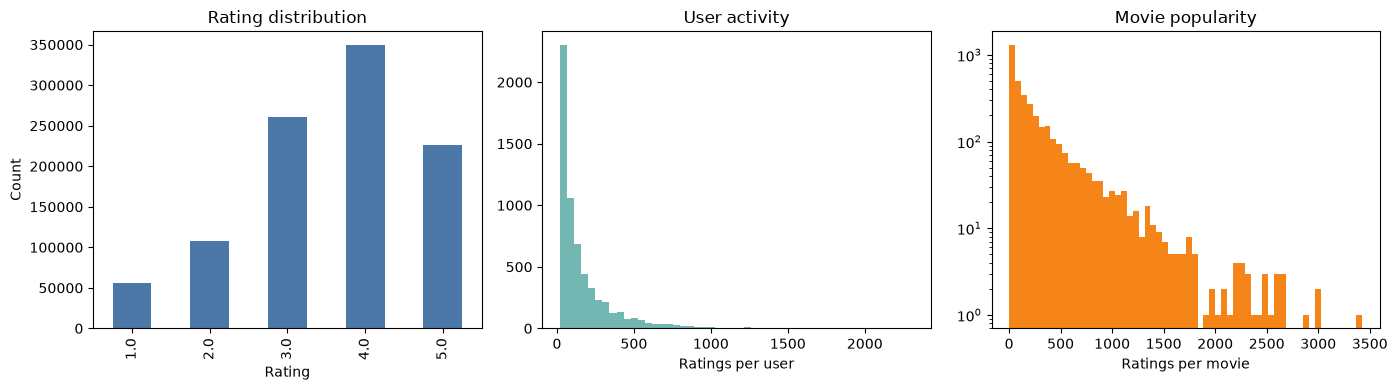

In [2]:
rating_counts = data.ratings["rating"].value_counts().sort_index()
user_activity = data.ratings.groupby("user_id").size()
movie_popularity = data.ratings.groupby("movie_id").size()
sparsity = 1.0 - len(data.ratings) / (
    data.users["user_id"].nunique() * data.movies["movie_id"].nunique()
)
display(pd.DataFrame([
    {"metric": "ratings", "value": len(data.ratings)},
    {"metric": "users", "value": data.ratings["user_id"].nunique()},
    {"metric": "rated_movies", "value": data.ratings["movie_id"].nunique()},
    {"metric": "matrix_sparsity", "value": sparsity},
    {"metric": "median_user_activity", "value": user_activity.median()},
    {"metric": "median_movie_popularity", "value": movie_popularity.median()},
]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rating_counts.plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set(title="Rating distribution", xlabel="Rating", ylabel="Count")
axes[1].hist(user_activity, bins=50, color="#72b7b2")
axes[1].set(title="User activity", xlabel="Ratings per user")
axes[2].hist(movie_popularity, bins=60, log=True, color="#f58518")
axes[2].set(title="Movie popularity", xlabel="Ratings per movie")
fig.tight_layout()
plt.show()

### 2.1 Temporal EDA

Interactions are distributed unevenly over time and timestamps preserve
ordering. Therefore ranking evaluation uses temporal
leave-one-positive-out. This does not change the main rating-prediction
split, which remains deterministic 70/15/15.

,minimum_date,maximum_date,months
0,2000-04-25 23:05:32+00:00,2003-02-28 17:49:50+00:00,35


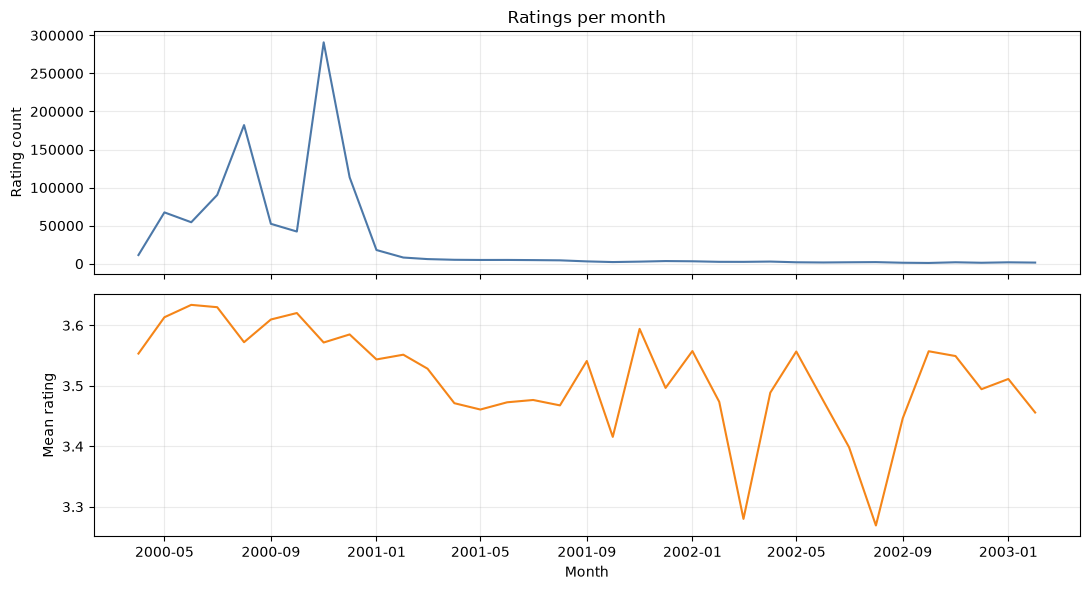

In [3]:
temporal = aggregate_temporal_ratings(data.ratings)
raw_dates = pd.to_datetime(data.ratings["timestamp"], unit="s", utc=True)
display(pd.DataFrame([{
    "minimum_date": raw_dates.min(),
    "maximum_date": raw_dates.max(),
    "months": len(temporal),
}]))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(temporal["month"], temporal["rating_count"], color="#4c78a8")
axes[0].set(title="Ratings per month", ylabel="Rating count")
axes[1].plot(temporal["month"], temporal["mean_rating"], color="#f58518")
axes[1].set(xlabel="Month", ylabel="Mean rating")
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### 2.2 Genre EDA

Genres are multi-label: one movie and one rating can contribute to
several genre rows, so genre counts are not mutually exclusive shares.
Genres are not model features. They are used only for post-hoc
interpretation, genre entropy, and latent-factor profiles.

,genre,movie_count,rating_count,mean_rating
0,Comedy,1200,356580,3.522099
1,Drama,1603,354529,3.766332
2,Action,503,257457,3.491185
3,Thriller,492,189680,3.570466
4,Sci-Fi,276,157294,3.466521
5,Romance,471,147523,3.607465
6,Adventure,283,133953,3.477257
7,Crime,211,79541,3.708678
8,Horror,343,76386,3.215013
9,Children's,251,72186,3.422035


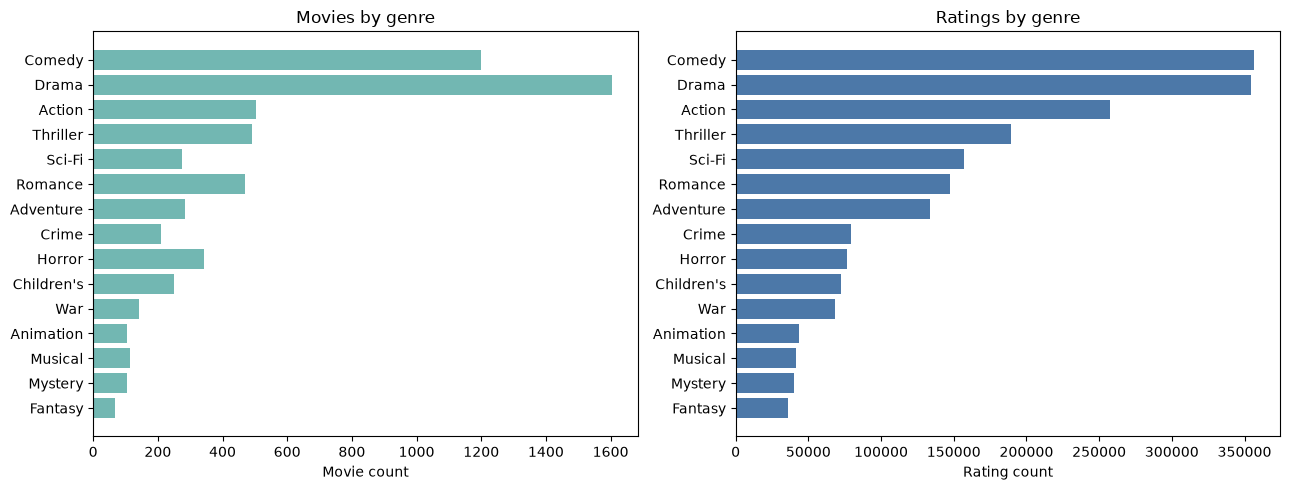

In [4]:
genre_summary = aggregate_genre_statistics(data.ratings, data.movies)
display(genre_summary)
view = genre_summary.sort_values("rating_count").tail(15)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(view["genre"], view["movie_count"], color="#72b7b2")
axes[0].set(title="Movies by genre", xlabel="Movie count")
axes[1].barh(view["genre"], view["rating_count"], color="#4c78a8")
axes[1].set(title="Ratings by genre", xlabel="Rating count")
fig.tight_layout()
plt.show()

### 2.3 Demographic EDA

Demographic attributes are explored only as dataset context. The
recommender models remain collaborative-only and do not use age, gender,
or occupation as input features. Labels below use the documented
MovieLens 1M age-group and occupation mappings.

,gender,user_count
0,M,4331
1,F,1709


,age_group,user_count
0,25-34,2096
1,35-44,1193
2,18-24,1103
3,45-49,550
4,50-55,496
5,56+,380
6,Under 18,222


,occupation_label,user_count
0,college/grad student,759
1,other/not specified,711
2,executive/managerial,679
3,academic/educator,528
4,technician/engineer,502
5,programmer,388
6,sales/marketing,302
7,writer,281
8,artist,267
9,self-employed,241


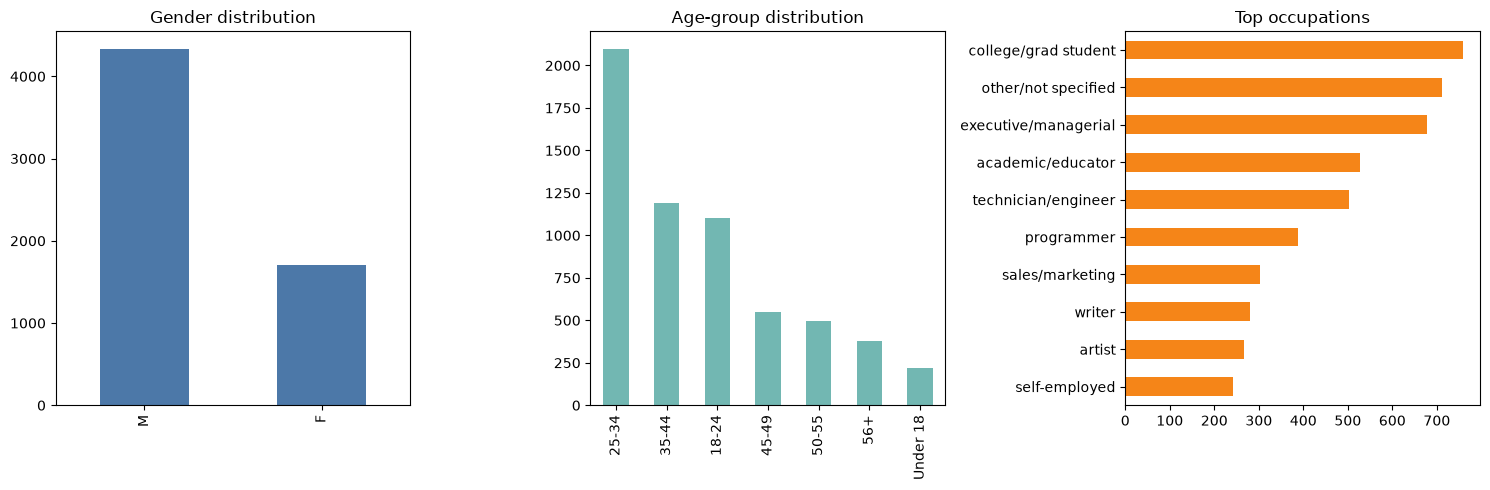

In [5]:
demographics = demographic_distributions(data.users)
display(demographics["gender"])
display(demographics["age_group"])
display(demographics["occupation"])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
demographics["gender"].plot.bar(
    x="gender", y="user_count", ax=axes[0], legend=False, color="#4c78a8"
)
demographics["age_group"].plot.bar(
    x="age_group", y="user_count", ax=axes[1], legend=False, color="#72b7b2"
)
demographics["occupation"].head(10).sort_values("user_count").plot.barh(
    x="occupation_label", y="user_count", ax=axes[2],
    legend=False, color="#f58518"
)
axes[0].set(title="Gender distribution", xlabel="")
axes[1].set(title="Age-group distribution", xlabel="")
axes[2].set(title="Top occupations", ylabel="")
fig.tight_layout()
plt.show()

## 3. Rating-prediction split

The pointwise protocol preserves the deterministic 70/15/15
interaction split. Validation selects hyperparameters and stopping; test
rows remain untouched until the final train-plus-validation refit.

In [6]:
display(pd.DataFrame([
    {"split": "train", "rows": len(train)},
    {"split": "validation", "rows": len(validation)},
    {"split": "test", "rows": len(test)},
]))
display(metrics["split"])

,split,rows
0,train,705806
1,validation,147201
2,test,147202


{'train_ratio': 0.7,
 'validation_ratio': 0.15,
 'test_ratio': 0.15,
 'actual_counts': {'train': 705806, 'validation': 147201, 'test': 147202}}

## 4. Bias baseline

BiasBaseline is a regularized ablation:
`global_mean + user_bias + item_bias`. Its regularization is selected
from validation data rather than hard-coded from a previous run.

In [7]:
display(pd.DataFrame(bias_tuning["results"]))
print("Selected:", bias_tuning["selected"])
print("Test MSE:", metrics["BiasBaseline_MSE"])
print("Test RMSE:", metrics["BiasBaseline_RMSE"])

,user_regularization,item_regularization,n_iterations,validation_mse,validation_rmse
0,1.0,1.0,20,0.820027,0.905553
1,2.0,2.0,20,0.819857,0.905459
2,5.0,5.0,20,0.820151,0.905622
3,10.0,10.0,20,0.821857,0.906564
4,20.0,20.0,20,0.827044,0.909419
5,40.0,40.0,20,0.839119,0.916034
6,80.0,80.0,20,0.862262,0.928581


Selected: {'user_regularization': 2.0, 'item_regularization': 2.0, 'n_iterations': 20, 'validation_mse': 0.8198565204045031, 'validation_rmse': 0.9054592869944529}
Test MSE: 0.8241185717756636
Test RMSE: 0.9078097662922908


## 5. Item-kNN neighborhood collaborative filtering

ItemKNN subtracts the fitted bias baseline, computes sparse item residual
vectors, applies cosine significance shrinkage, and keeps pairs with at
least three common users. Prediction uses signed similarities in the
numerator and absolute similarities in the denominator.

In [8]:
item_results = pd.DataFrame(item_knn_tuning["results"])
display(item_results.sort_values(["validation_rmse", "k", "shrinkage"]).head(9))
print("Selected:", item_knn_tuning["selected"])
print("Test MSE:", metrics["ItemKNN_MSE"])
print("Test RMSE:", metrics["ItemKNN_RMSE"])
print("Neighbor diagnostics:", item_knn_tuning["final_refit"]["diagnostics"])

,k,shrinkage,min_common,validation_mse,validation_rmse
8,80,100.0,3,0.751759,0.867040
5,80,50.0,3,0.755316,0.869089
2,80,10.0,3,0.771397,0.878292
7,40,100.0,3,0.776173,0.881007
4,40,50.0,3,0.782128,0.884380
1,40,10.0,3,0.805781,0.897653
6,20,100.0,3,0.821682,0.906467
3,20,50.0,3,0.829216,0.910613
0,20,10.0,3,0.857278,0.925893


Selected: {'k': 80, 'shrinkage': 100.0, 'min_common': 3, 'validation_mse': 0.7517586090141275, 'validation_rmse': 0.8670401426774469}
Test MSE: 0.737614389002035
Test RMSE: 0.8588447991354637
Neighbor diagnostics: {'stored_neighbor_count': 274545, 'similarities_finite': True, 'minimum_similarity': -0.09016324404620857, 'maximum_similarity': 0.377741504898087, 'minimum_common_users': 3, 'self_neighbor_count': 0, 'deterministic_ordering_verified': True}


## 6. SVD methodology and tuning

SVD factorizes a user-mean-centered sparse matrix with a regularized item
residual bias. Raw predictions are retained for ranking; clipping is used
only for rating evaluation and display.

SVD is fitted through a direct truncated decomposition and therefore has
no epoch-based learning curve. These plots show validation error across
the tested ranks and document the rank-selection decision.

,n_factors,item_bias_regularization,validation_mse,validation_rmse
7,20,5,0.803190,0.896209
2,20,0,0.803300,0.896270
12,20,10,0.804237,0.896792
8,40,5,0.804823,0.897119
3,40,0,0.804881,0.897152
13,40,10,0.805925,0.897733
17,20,20,0.806875,0.898262
6,10,5,0.807206,0.898446
1,10,0,0.807441,0.898577
11,10,10,0.808181,0.898989


Selected SVD parameters: {'n_factors': 20, 'item_bias_regularization': 5.0}


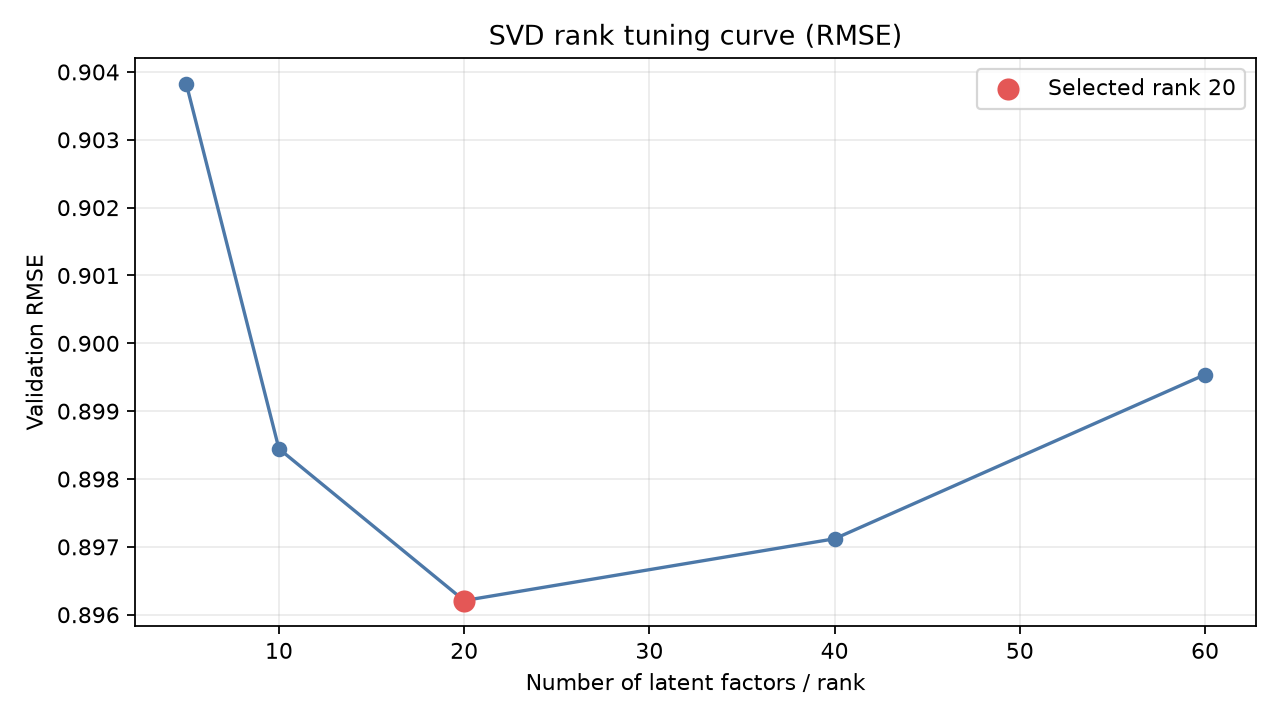

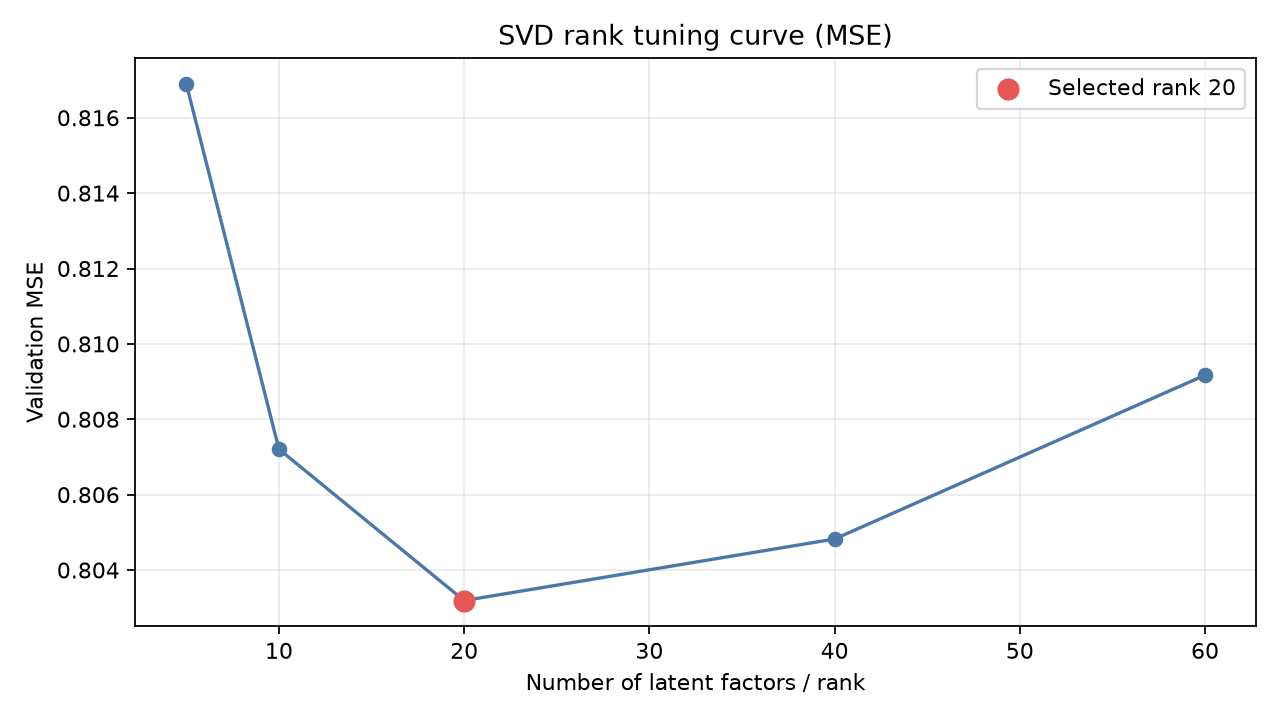

In [9]:
display(svd_tuning.sort_values("validation_rmse").head(10))
print("Selected SVD parameters:", metrics["svd_best_params"])
display(Image(filename=str(REPORTS / "svd_rank_tuning_rmse.png")))
display(Image(filename=str(REPORTS / "svd_rank_tuning_mse.png")))

## 7. PMF methodology and tuning

PMF learns user/item biases and latent interactions with seeded SGD. The
preserved grid searches 96/112/128 factors and factor regularization
0.05/0.06/0.07 at learning rate 0.006 and bias regularization 0.02.

In [10]:
display(pmf_tuning.sort_values("validation_rmse"))
print("Selected PMF parameters:", metrics["pmf_best_params"])

,n_factors,learning_rate,factor_regularization,bias_regularization,best_epoch,validation_rmse,epochs_run,hit_epoch_cap,hit_factor_boundary
7,128,0.006,0.06,0.02,53,0.849353,61,False,True
6,128,0.006,0.05,0.02,40,0.849747,48,False,True
4,112,0.006,0.06,0.02,53,0.849830,61,False,False
1,96,0.006,0.06,0.02,53,0.850033,61,False,False
8,128,0.006,0.07,0.02,68,0.850417,70,False,True
3,112,0.006,0.05,0.02,41,0.850464,49,False,False
5,112,0.006,0.07,0.02,68,0.850715,70,False,False
0,96,0.006,0.05,0.02,40,0.850756,48,False,False
2,96,0.006,0.07,0.02,68,0.850899,70,False,False


Selected PMF parameters: {'n_factors': 128, 'learning_rate': 0.006, 'factor_regularization': 0.06, 'bias_regularization': 0.02, 'selected_epoch': 53, 'validation_rmse': 0.8493525385856628}


## 8. Convergence, regularization and stopping

PMF convergence is a genuine epoch-based learning curve. Both views show
train and validation history, the selected epoch, and early-stopping
context. MSE is derived unambiguously as `RMSE ** 2`.

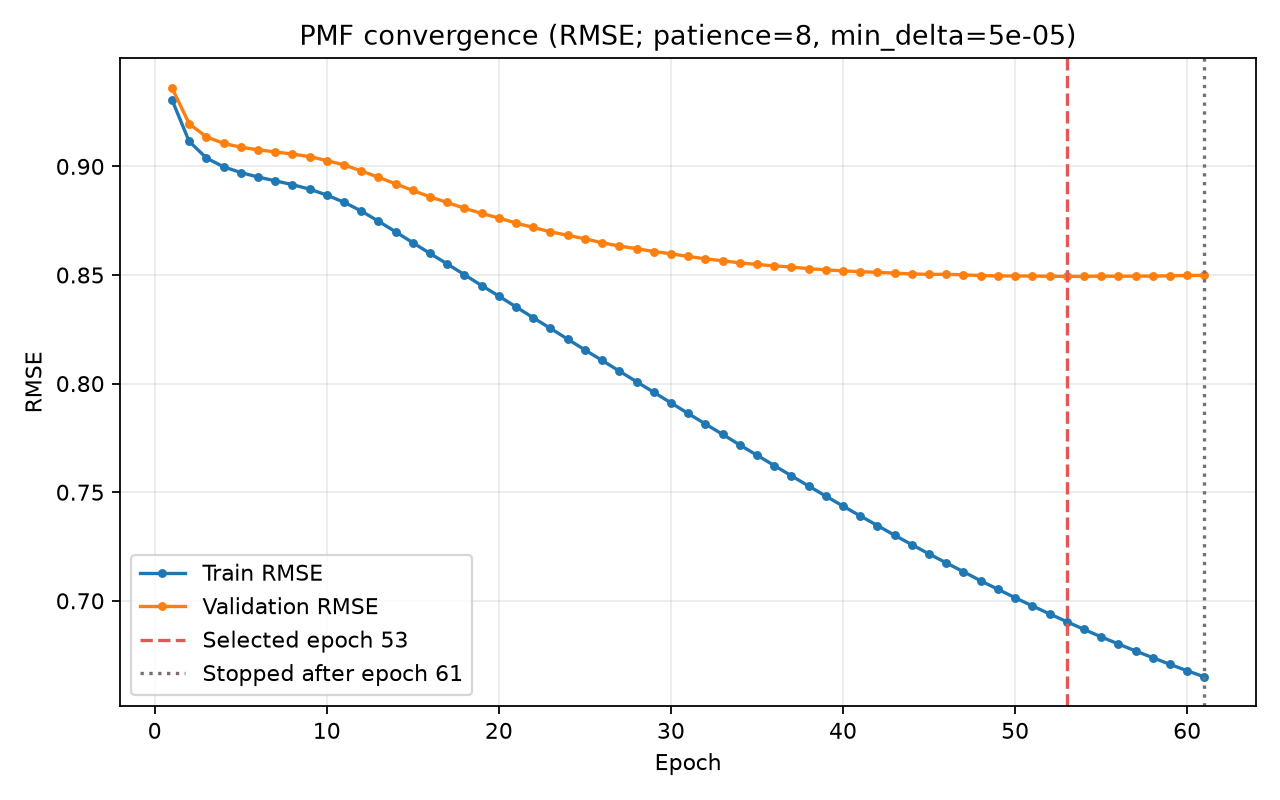

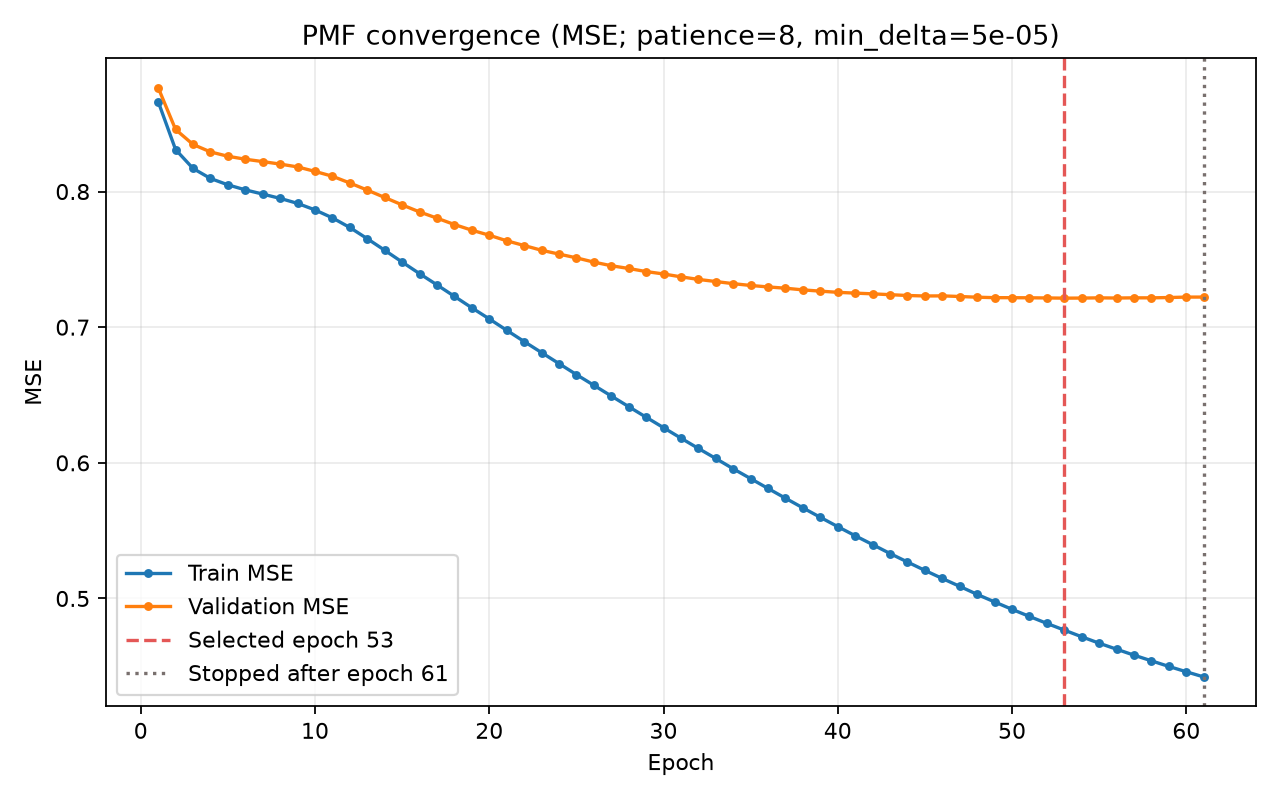

,epoch,train_rmse,validation_rmse,train_mse,validation_mse
56,57,0.676918,0.849492,0.458218,0.721637
57,58,0.673823,0.849490,0.454037,0.721633
58,59,0.670751,0.849623,0.449907,0.721860
59,60,0.667812,0.849817,0.445973,0.722188
60,61,0.664961,0.849819,0.442174,0.722193


Final refit epochs: 53
Early stopping: {'patience': 8, 'min_delta': 5e-05, 'epochs_run': 61, 'triggered': True}
Search diagnostics: {'selected_at_factor_boundary': True, 'selected_at_epoch_boundary': False, 'selected_early_stopping_triggered': True, 'search_max_factors': 128, 'search_max_epochs': 70}


In [11]:
display(Image(filename=str(REPORTS / "pmf_convergence.png")))
display(Image(filename=str(REPORTS / "pmf_convergence_mse.png")))
display(pd.DataFrame(pmf_convergence["history"]).tail())
pmf_metadata = load_json(REPORTS / "pmf_factors" / "metadata.json")
print("Final refit epochs:", pmf_metadata["config"]["epochs"])
print("Early stopping:", pmf_convergence["early_stopping"])
print("Search diagnostics:", metrics["pmf_search_diagnostics"])

## 9. Rating-prediction results

All four models use the same untouched rating test rows. MSE and RMSE are
shown separately rather than sharing one axis.

,model,test_mse,test_rmse
0,BiasBaseline,0.824119,0.907810
1,ItemKNN,0.737614,0.858845
2,SVD,0.793518,0.890796
3,PMF,0.712165,0.843899


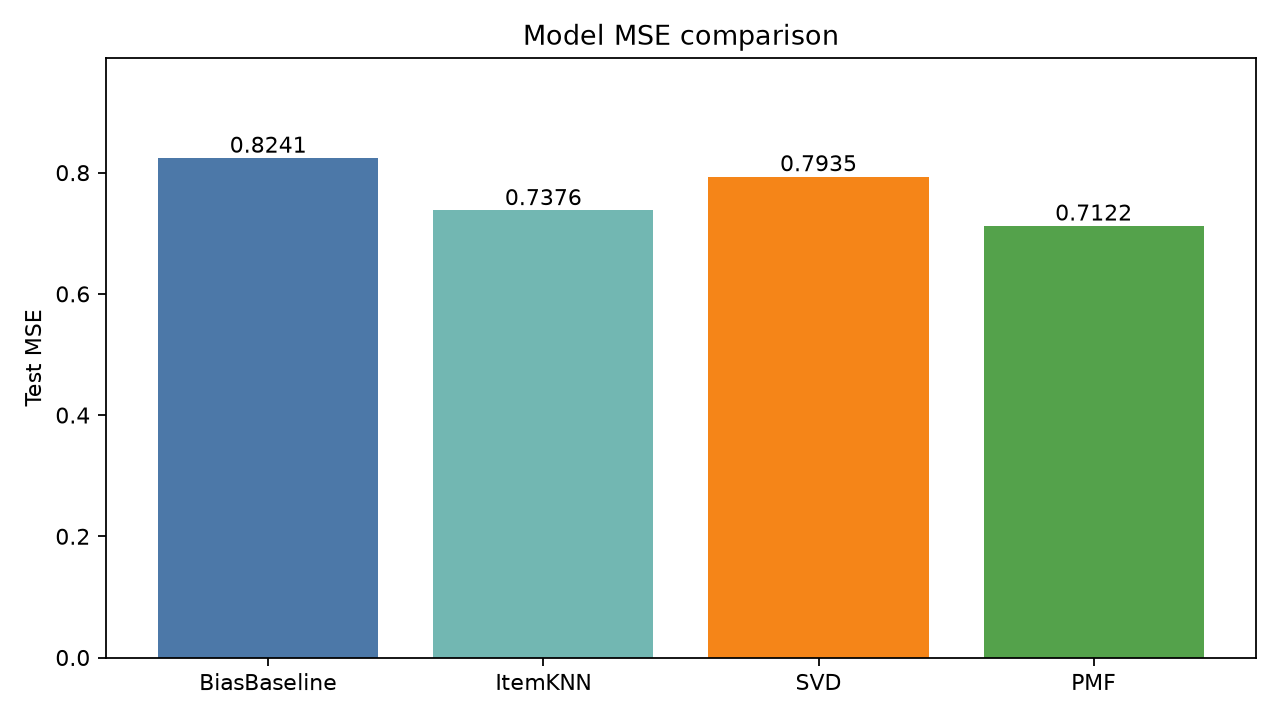

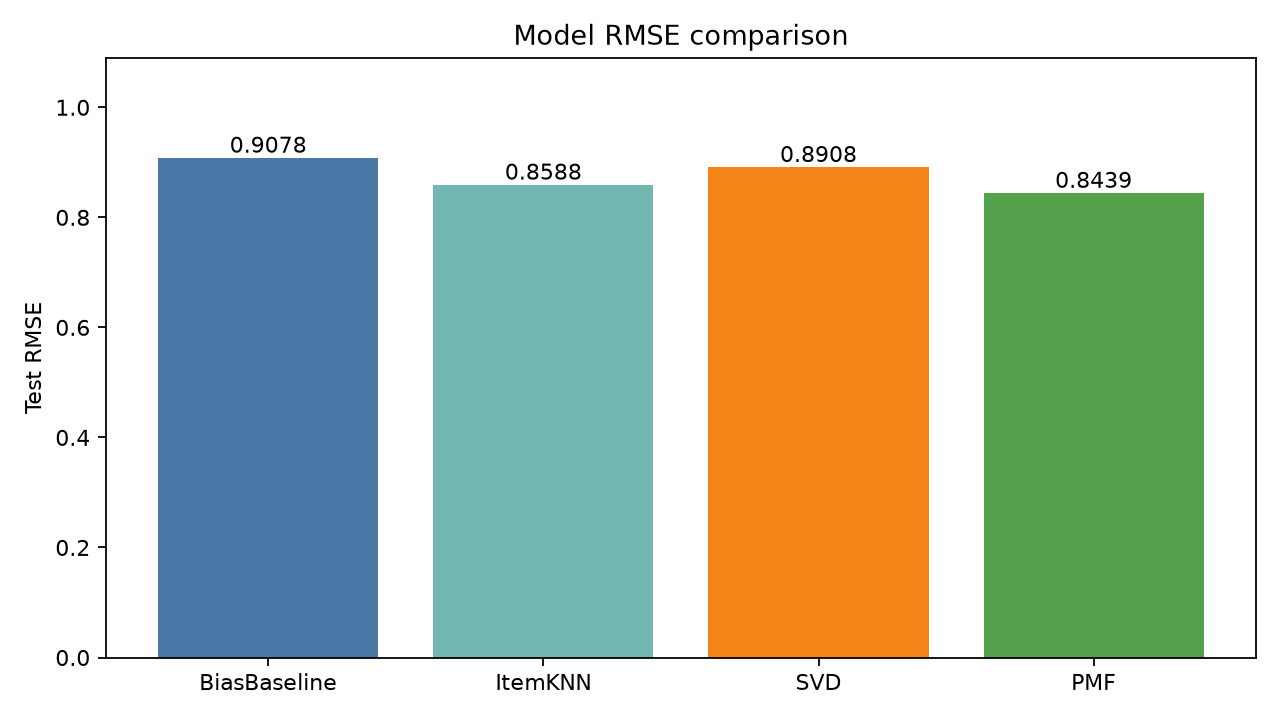

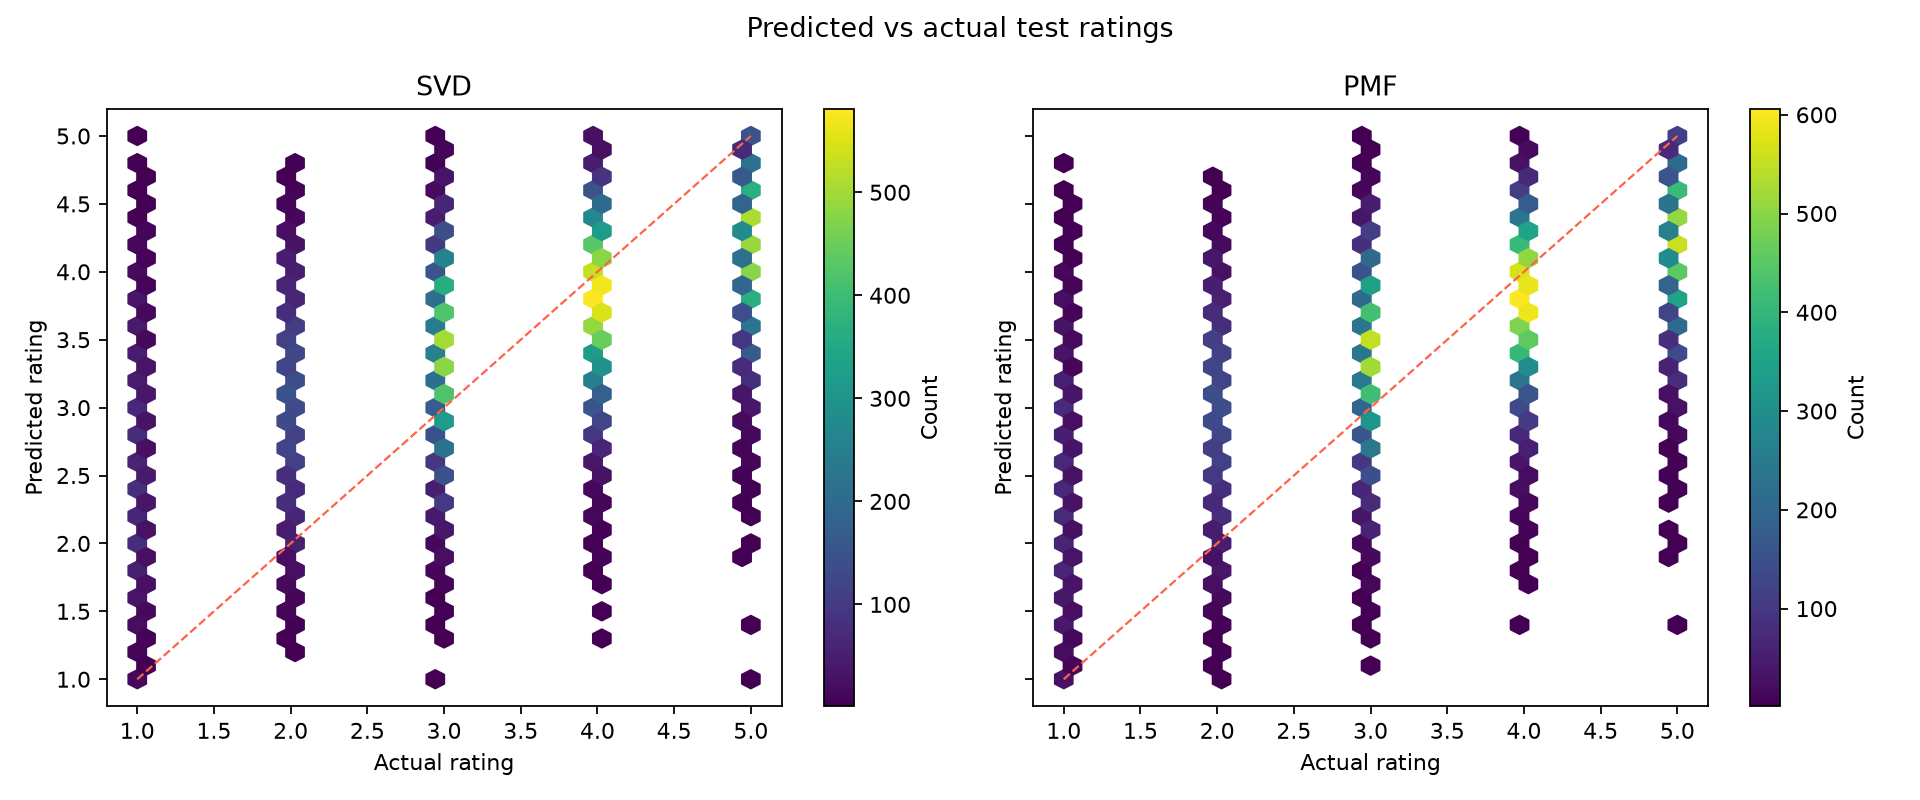

In [12]:
rating_table = build_rating_table(metrics)
display(rating_table)
display(Image(filename=str(REPORTS / "model_mse_comparison.png")))
display(Image(filename=str(REPORTS / "rmse_comparison.png")))
display(Image(filename=str(REPORTS / "predicted_vs_actual.png")))

## 10. Temporal leave-one-positive-out protocol

Each eligible user contributes one known future positive: the latest
rating at least 4.0, with movie ID ascending as the same-timestamp
tie-break. Ranking history is strictly `timestamp < target_timestamp`;
same-timestamp and later interactions are excluded. Users need at least
20 prior interactions, and targets need at least 10 ranking-training
interactions.

Candidate movies are the full ranking-training-supported catalog minus
the user's prefix history. No sampled negatives are used. Unknown catalog
items are not observed negatives.

In [13]:
display(pd.Series(ranking_protocol).to_frame("value"))
display(ranking_targets.head())
print("Ranking training rows:", len(ranking_train))

,value
protocol,next-positive recovery under temporal leave-on...
positive_threshold,4.0
target_selection,latest rating >= threshold; movie_id ascending...
history_rule,timestamp < target_timestamp
same_timestamp_and_later_interactions_excluded,True
min_prior_interactions,20
min_target_item_support,10
full_catalog_candidates,True
sampled_negatives,False
unknown_items_are_observed_negatives,False


,user_id,movie_id,rating,timestamp,prior_history_count,target_item_support
0,1,48,5.0,978824351,52,368
1,2,1544,4.0,978300174,125,1196
2,3,2081,4.0,978298504,50,1009
3,5,2029,4.0,978246555,193,71
4,6,597,5.0,978239019,70,1030


Ranking training rows: 974610


## 11. Top-K ranking results

HitRate/NDCG/MRR measure next-positive recovery for the single held-out
target. Recall is not reported separately because with one target it is
identical to HitRate.

,model,eligible_user_count,mean_target_rank,median_target_rank,HitRate@5,NDCG@5,MRR@5,HitRate@10,NDCG@10,MRR@10
0,BiasBaseline,5767.0,1148.594243,934.0,0.004682,0.002093,0.001283,0.013178,0.004714,0.002291
1,ItemKNN,5767.0,1084.283510,845.0,0.002601,0.001599,0.001269,0.005375,0.002502,0.001645
2,SVD,5767.0,1097.460378,796.0,0.019421,0.011453,0.008841,0.030692,0.015065,0.010313
3,PMF,5767.0,975.601353,696.0,0.014392,0.009064,0.007338,0.026704,0.012976,0.008912


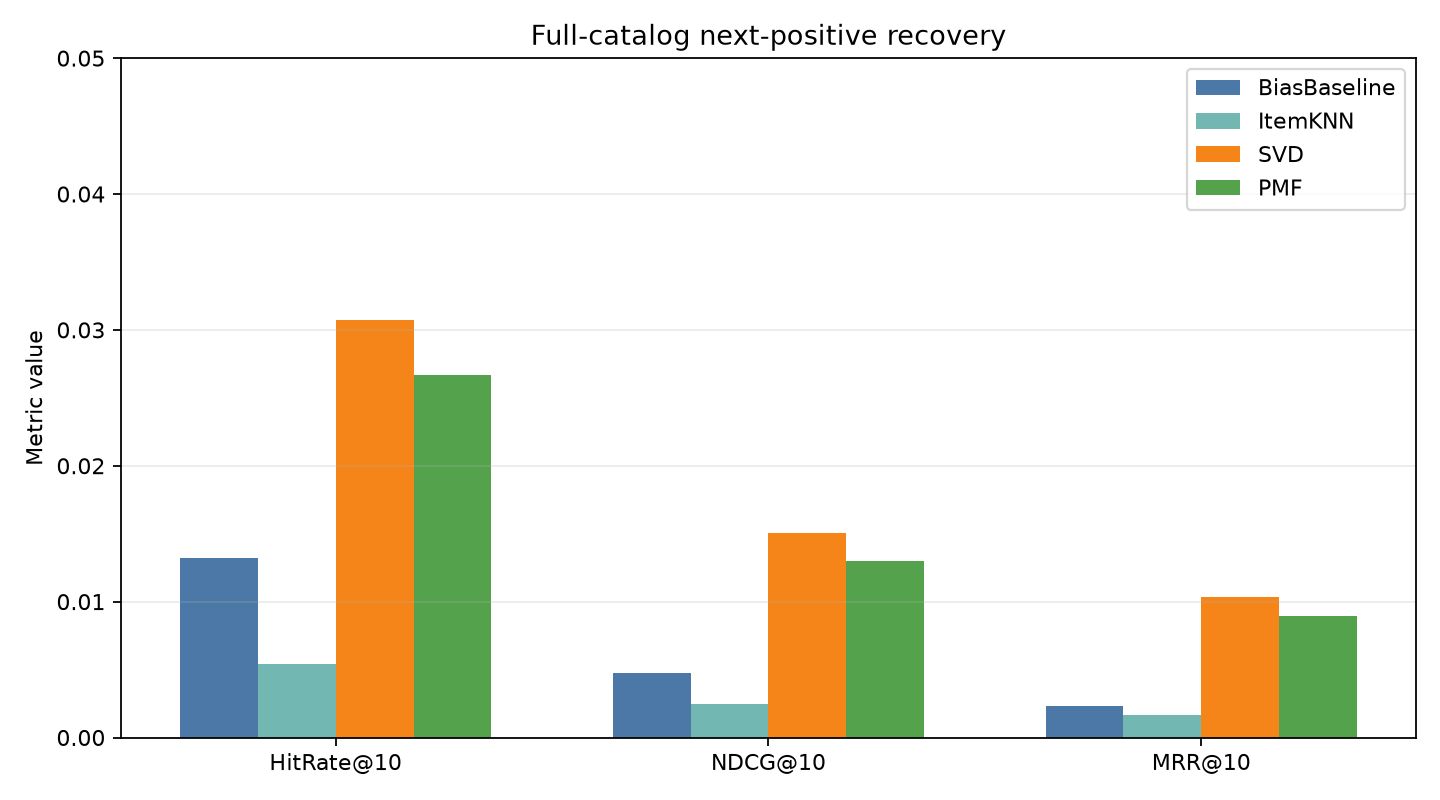

,user_id,target_movie_id,target_title,target_genres,target_rating,target_timestamp,prior_history_count,candidate_count,bias_target_rank,bias_raw_target_score,...,svd_ndcg_at_10,svd_mrr_at_10,pmf_target_rank,pmf_raw_target_score,pmf_hit_at_5,pmf_ndcg_at_5,pmf_mrr_at_5,pmf_hit_at_10,pmf_ndcg_at_10,pmf_mrr_at_10
0,1,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351,52,3648,2668,3.204421,...,0.0,0.0,1887,3.488207,False,0.0,0.0,False,0.0,0.0
1,2,1544,"Lost World: Jurassic Park, The (1997)",Action|Adventure|Sci-Fi|Thriller,4.0,978300174,125,3575,2542,2.963435,...,0.0,0.0,1638,3.272778,False,0.0,0.0,False,0.0,0.0
2,3,2081,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance,4.0,978298504,50,3650,972,3.851006,...,0.0,0.0,1563,3.565609,False,0.0,0.0,False,0.0,0.0
3,5,2029,Billy's Hollywood Screen Kiss (1997),Comedy|Romance,4.0,978246555,193,3507,744,3.234458,...,0.0,0.0,1150,2.974982,False,0.0,0.0,False,0.0,0.0
4,6,597,Pretty Woman (1990),Comedy|Romance,5.0,978239019,70,3630,1201,3.909067,...,0.0,0.0,88,4.262119,False,0.0,0.0,False,0.0,0.0


In [14]:
ranking_table = pd.DataFrame(ranking_metrics["models"]).T.reset_index(
    names="model"
)
display(ranking_table)
display(Image(filename=str(REPORTS / "ranking_comparison.png")))
display(ranking_results.head())

### Rating accuracy vs ranking

The implementation below is reusable project code. It validates model
coverage and rank-derived metrics, applies deterministic tie handling,
computes metric reversals and target-rank quantiles, and prepares the
comparison plot.

model,test_mse,test_rmse,HitRate@5,HitRate@10,median_target_rank,share_target_rank_gt_2000,rmse_position,hit_rate_10_position
PMF,0.712,0.844,1.44%,2.67%,696,16.09%,1,2
ItemKNN,0.738,0.859,0.26%,0.54%,845,17.83%,2,4
SVD,0.794,0.891,1.94%,3.07%,796,21.03%,3,1
BiasBaseline,0.824,0.908,0.47%,1.32%,934,20.62%,4,3


,model,rmse_position,hit_rate_10_position,position_change
0,PMF,1,2,1
1,ItemKNN,2,4,2
2,SVD,3,1,-2
3,BiasBaseline,4,3,-1


model,p1,p5,p10,p25,p50,p75,p90,p95,p99,share_rank_gt_2000,per_user_better_share
SVD,3.0,21.0,59.0,238.5,796.0,1822.5,2597.8,3032.0,3429.3,21.03%,40.5%
PMF,4.0,24.0,56.0,220.5,696.0,1536.5,2374.6,2794.5,3285.0,16.09%,59.0%


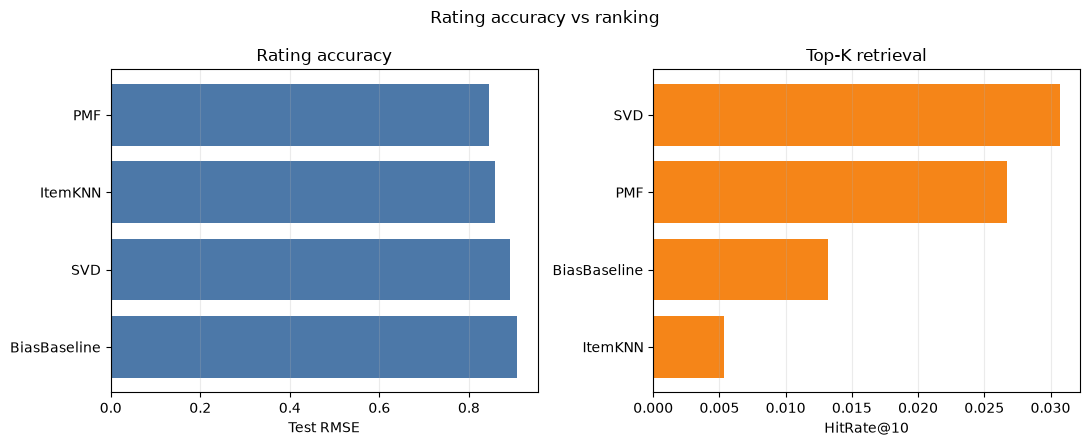

By test RMSE: PMF (0.844) < ItemKNN (0.859) < SVD (0.891) < BiasBaseline (0.908). By HitRate@10: SVD (3.07%) > PMF (2.67%) > BiasBaseline (1.32%) > ItemKNN (0.54%). PMF is #1 by RMSE and #2 by HitRate@10. ItemKNN is #2 by RMSE and #4 by HitRate@10. SVD is #3 by RMSE and #1 by HitRate@10. BiasBaseline is #4 by RMSE and #3 by HitRate@10. Deep-tail shares above rank 2,000 are SVD 21.03% and PMF 16.09%. Per user, PMF has the lower target rank in 59.0% of cases, SVD in 40.5%, with 0.5% ties. Rating prediction and top-K retrieval answer different questions, so the preferred model depends on the evaluation objective.

In [15]:
rating_ranking = load_rating_ranking_analysis(REPORTS)
display(rating_ranking.comparison_table.style.hide(axis="index").format({
    "test_mse": "{:.3f}",
    "test_rmse": "{:.3f}",
    "HitRate@5": "{:.2%}",
    "HitRate@10": "{:.2%}",
    "median_target_rank": "{:.0f}",
    "share_target_rank_gt_2000": "{:.2%}",
}))
display(rating_ranking.reversal_table)
display(rating_ranking.rank_distribution_table.style.hide(axis="index").format({
    **{column: "{:.1f}" for column in [
        "p1", "p5", "p10", "p25", "p50", "p75", "p90", "p95", "p99"
    ]},
    "share_rank_gt_2000": "{:.2%}",
    "per_user_better_share": "{:.1%}",
}))
figure = plot_rating_ranking_tradeoff(rating_ranking.plot_data)
display(figure)
plt.close(figure)
display(Markdown(rating_ranking.interpretation))

## 12. Global latent-factor interpretation

High-variance PMF factors are described from movies and genres on both
poles. Factor sign is arbitrary, so these are descriptive patterns rather
than objective semantic dimensions.

,factor_index,factor_variance,polarity,polarity_rank,movie_id,title,genres,factor_loading
0,123,0.017044,positive,1,3688,Porky's (1981),Comedy,0.644381
1,123,0.017044,positive,2,3431,Death Wish II (1982),Action|Drama,0.483069
2,123,0.017044,positive,3,3689,Porky's II: The Next Day (1983),Comedy,0.415265
3,123,0.017044,positive,4,1855,Krippendorf's Tribe (1998),Comedy,0.411035
4,123,0.017044,positive,5,3433,Death Wish 4: The Crackdown (1987),Action|Drama,0.402932
5,123,0.017044,positive,6,2411,Rocky IV (1985),Action|Drama,0.400579
6,123,0.017044,positive,7,2961,"Story of Us, The (1999)",Comedy|Drama,0.398805
7,123,0.017044,positive,8,3577,Two Moon Juction (1988),Drama,0.395567
8,123,0.017044,negative,1,2710,"Blair Witch Project, The (1999)",Horror,-0.496847
9,123,0.017044,negative,2,532,Serial Mom (1994),Comedy|Crime|Horror,-0.425156


,factor_index,polarity,genre,movie_count,genre_share,mean_factor_loading
0,10,negative,Horror,5,0.500000,-0.383474
1,10,negative,Drama,2,0.200000,-0.462993
2,10,negative,Crime,1,0.100000,-0.384618
3,10,negative,Sci-Fi,1,0.100000,-0.422868
4,10,negative,Thriller,1,0.100000,-0.384618
5,10,positive,Comedy,8,0.500000,0.457878
6,10,positive,Romance,3,0.187500,0.485245
7,10,positive,Drama,2,0.125000,0.447801
8,10,positive,Action,1,0.062500,0.450484
9,10,positive,Documentary,1,0.062500,0.432814


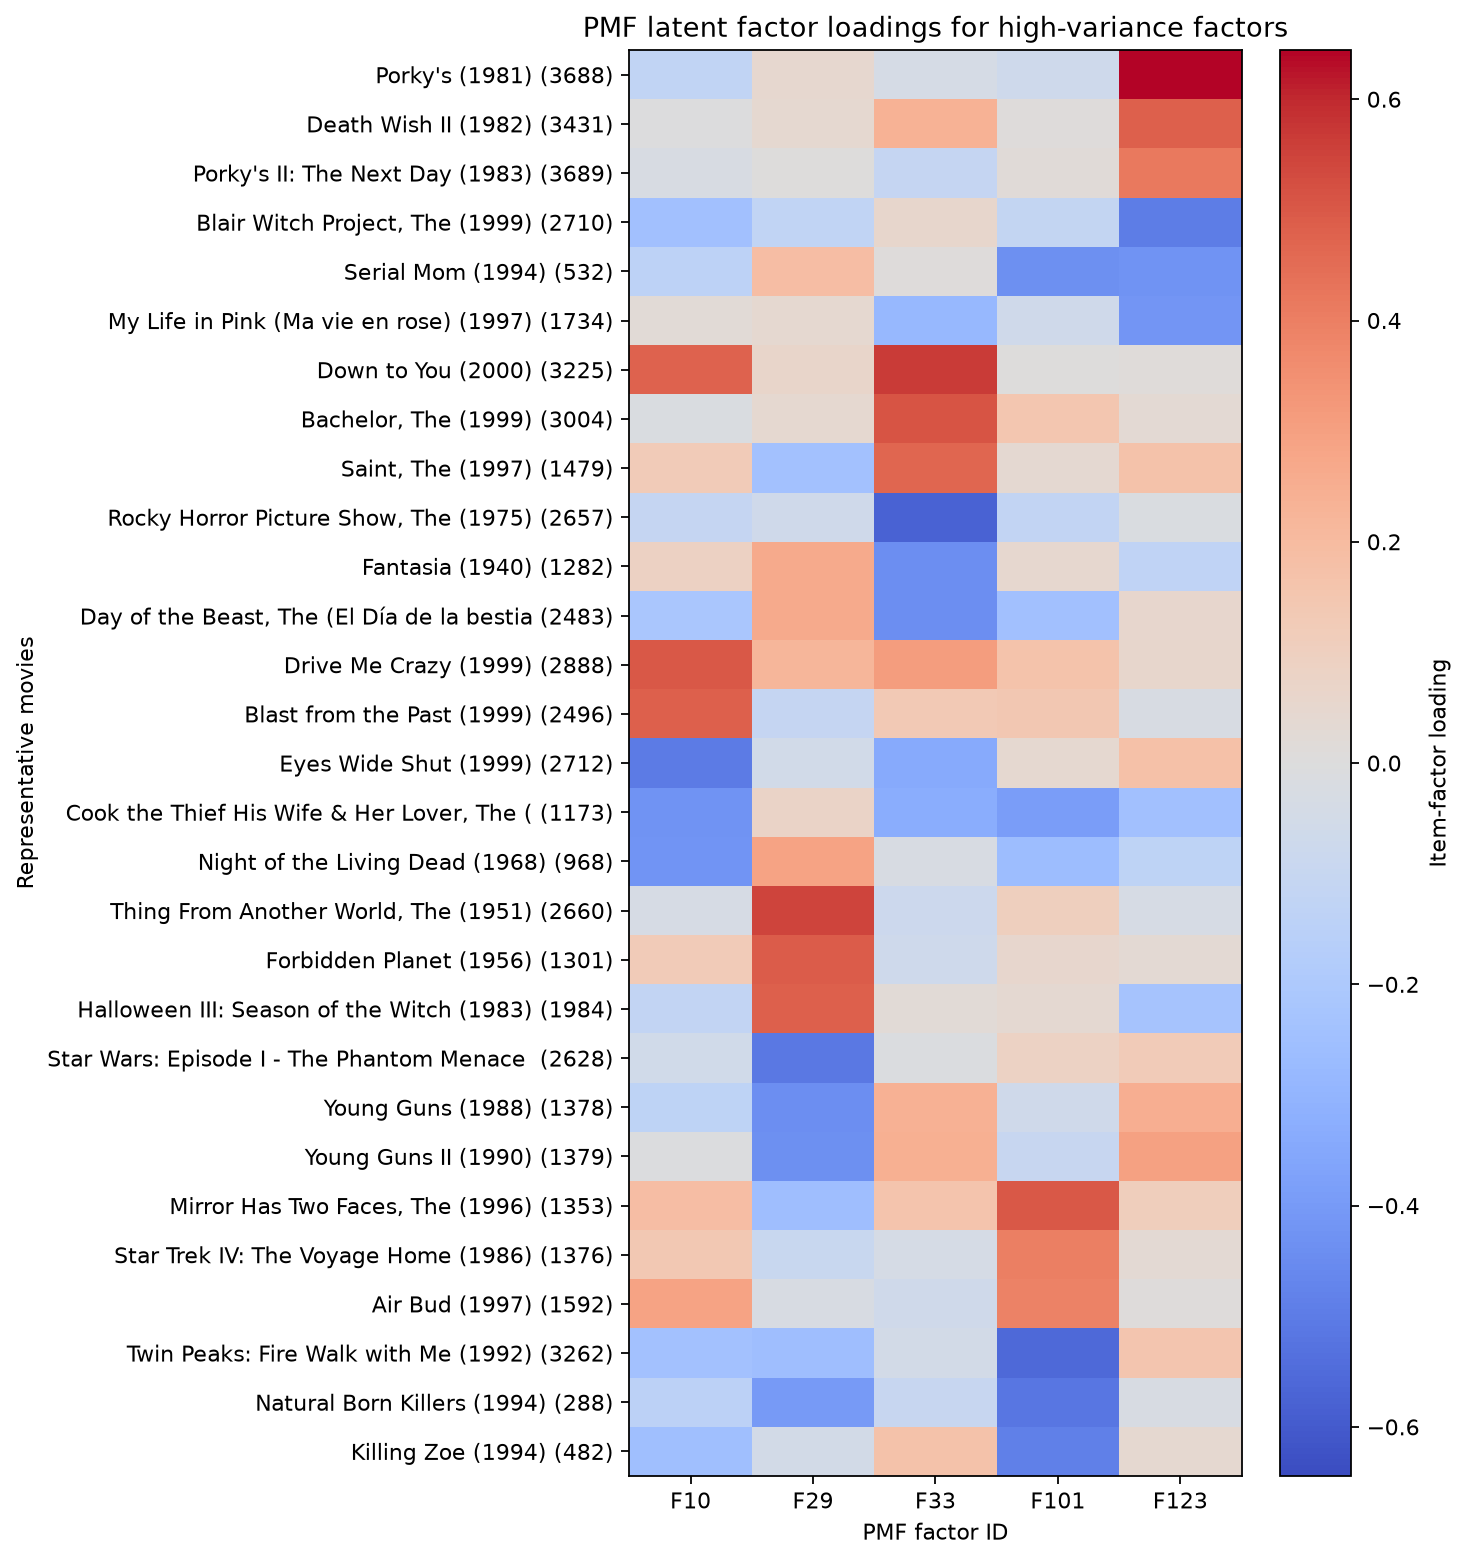

In [16]:
display(factor_interpretation.head(20))
display(factor_genre_profiles.head(20))
display(Image(filename=str(REPORTS / "pmf_latent_factor_heatmap.png")))

## 13. Movie similarity analysis

Similarity uses cosine distance between final production PMF item-factor
vectors. Self-matches are excluded and rows are deterministically sorted.

In [17]:
display(similarities.head(30))
print(
    "Similarity range:",
    similarities["cosine_similarity"].min(),
    similarities["cosine_similarity"].max(),
)

,anchor_movie_id,anchor_title,anchor_genres,similar_movie_id,similar_title,similar_genres,cosine_similarity,rank
0,2858,American Beauty (1999),Comedy|Drama,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,0.544902,1
1,2858,American Beauty (1999),Comedy|Drama,1222,Full Metal Jacket (1987),Action|Drama|War,0.535649,2
2,2858,American Beauty (1999),Comedy|Drama,296,Pulp Fiction (1994),Crime|Drama,0.520803,3
3,2858,American Beauty (1999),Comedy|Drama,1728,"Winter Guest, The (1997)",Drama,0.513478,4
4,2858,American Beauty (1999),Comedy|Drama,2997,Being John Malkovich (1999),Comedy,0.494339,5
5,2858,American Beauty (1999),Comedy|Drama,50,"Usual Suspects, The (1995)",Crime|Thriller,0.489682,6
6,2858,American Beauty (1999),Comedy|Drama,3317,Wonder Boys (2000),Comedy|Drama,0.478323,7
7,2858,American Beauty (1999),Comedy|Drama,1673,Boogie Nights (1997),Drama,0.473511,8
8,2858,American Beauty (1999),Comedy|Drama,3949,Requiem for a Dream (2000),Drama,0.469242,9
9,2858,American Beauty (1999),Comedy|Drama,3171,Room at the Top (1959),Drama,0.465240,10


Similarity range: 0.439644473662361 0.9368732065528416


## 14. User Case Studies

The 70/15/15 split is performed over each user's interactions, so the
same user may appear in train, validation, and test. `test_case` means a
held-out interaction case, not an unseen or cold-start user. Cold start is
outside scope; user 2210 has training history and is evaluated on a
held-out future interaction.

Roles `train_profile_accurate`, `train_profile_less_accurate`, and
`test_case` are defined by temporal ranking outcome, not per-user RMSE.
User 2739 is `accurate` because PMF achieves Hit@10; user 2505 is
`less_accurate` because PMF misses Hit@10. These labels do not imply lower
PMF per-user RMSE: PMF can be worse than SVD for user 2739, while user
2505 can have very low SVD RMSE. This is expected because rating
prediction and ranking answer different questions.

In [18]:
case_columns = [
    "role", "user_id", "ranking_case", "ranking_target_movie_id",
    "ranking_target_title", "ranking_target_rating",
    "ranking_history_count", "ranking_candidate_count",
    "bias_target_rank", "item_knn_target_rank", "svd_target_rank",
    "pmf_target_rank", "bias_hit_at_10", "item_knn_hit_at_10",
    "svd_hit_at_10", "pmf_hit_at_10", "svd_test_rmse", "pmf_test_rmse",
]
display(evaluated[case_columns])

,role,user_id,ranking_case,ranking_target_movie_id,ranking_target_title,ranking_target_rating,ranking_history_count,ranking_candidate_count,bias_target_rank,item_knn_target_rank,svd_target_rank,pmf_target_rank,bias_hit_at_10,item_knn_hit_at_10,svd_hit_at_10,pmf_hit_at_10,svd_test_rmse,pmf_test_rmse
0,train_profile_accurate,2739,pmf_hit_at_10,2762,"Sixth Sense, The (1999)",4.0,30,3670,42,127,11,6,False,False,False,True,0.845575,0.917201
1,train_profile_less_accurate,2505,pmf_miss_at_10,317,"Santa Clause, The (1994)",4.0,31,3669,2313,83,2378,736,False,False,False,False,0.533738,0.910851
2,test_case,2210,representative_target_rank,3952,"Contender, The (2000)",5.0,24,3676,817,2106,729,696,False,False,False,False,0.918175,1.068985


## 15. Recommendation Hit vs Miss Analysis

The accurate profile is a PMF Hit@10 and the less-accurate profile is a
PMF miss. Score components and profile summaries may help interpret a
result, but they do not establish causality.

,user_id,role,ranking_case,selection_reason,train_ratings,validation_ratings,test_ratings,svd_test_rmse,pmf_test_rmse,ranking_target_movie_id,...,ranking_history_count,ranking_candidate_count,bias_target_rank,item_knn_target_rank,svd_target_rank,pmf_target_rank,bias_hit_at_10,item_knn_hit_at_10,svd_hit_at_10,pmf_hit_at_10
0,2739,train_profile_accurate,pmf_hit_at_10,Supported PMF Hit@10 user nearest the median n...,24,4,4,0.845575,0.917201,2762,...,30,3670,42,127,11,6,False,False,False,True
1,2505,train_profile_less_accurate,pmf_miss_at_10,Supported PMF miss user nearest the median PMF...,24,4,4,0.533738,0.910851,317,...,31,3669,2313,83,2378,736,False,False,False,False



train_profile_accurate: user 2739


,user_id,role,ranking_case,target_movie_id,target_title,target_genres,target_rating,target_timestamp,prior_history_count,candidate_count,...,top_factor_2_contribution,top_factor_3_index,top_factor_3_contribution,top_factor_contributions,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2739,train_profile_accurate,pmf_hit_at_10,2762,"Sixth Sense, The (1999)",Thriller,4.0,973224971,30,3670,...,0.014968,15,0.012904,"[{""contribution"": 0.018696115714840644, ""facto...",3408,Erin Brockovich (2000),Drama,4.0,0.348877,NaN


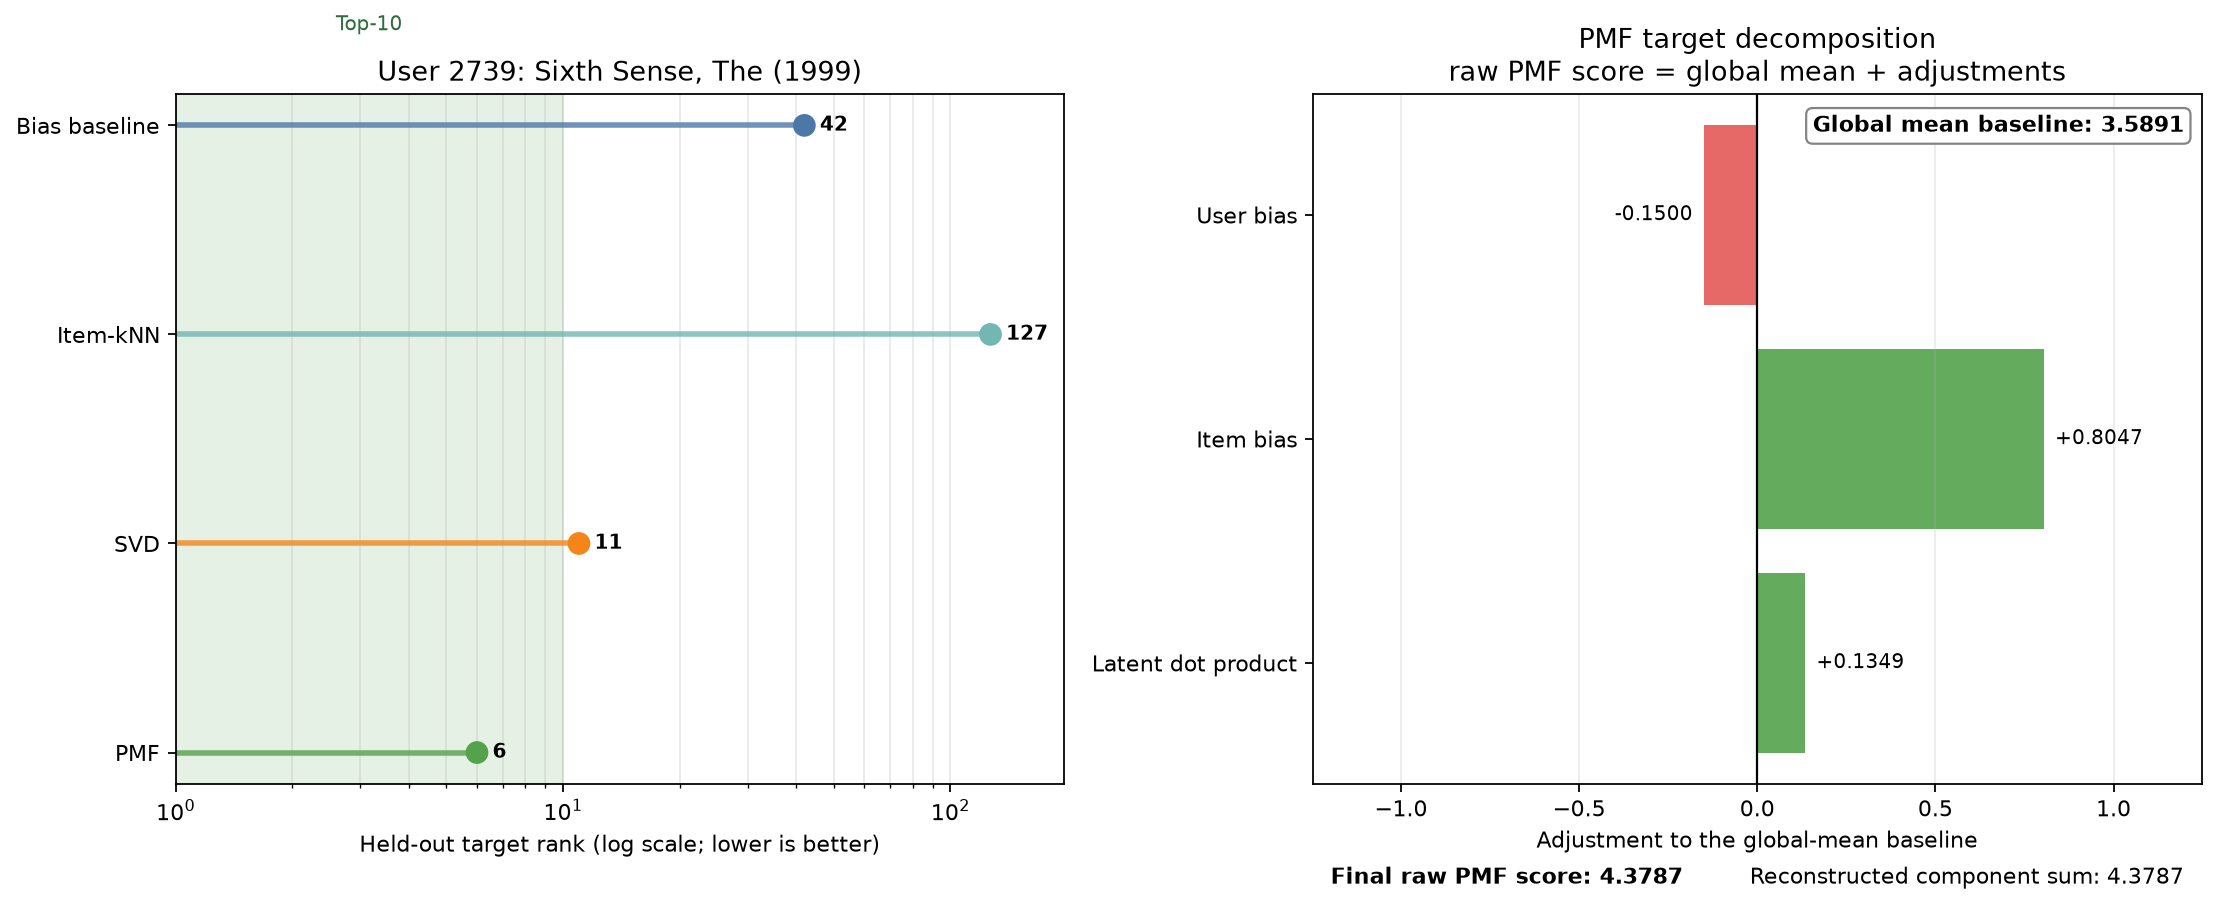


train_profile_less_accurate: user 2505


,user_id,role,ranking_case,target_movie_id,target_title,target_genres,target_rating,target_timestamp,prior_history_count,candidate_count,...,top_factor_2_contribution,top_factor_3_index,top_factor_3_contribution,top_factor_contributions,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2505,train_profile_less_accurate,pmf_miss_at_10,317,"Santa Clause, The (1994)",Children's|Comedy|Fantasy,4.0,1007830269,31,3669,...,0.048488,46,0.035736,"[{""contribution"": 0.05754974971572313, ""factor...",1608,Air Force One (1997),Action|Thriller,5.0,0.426195,NaN


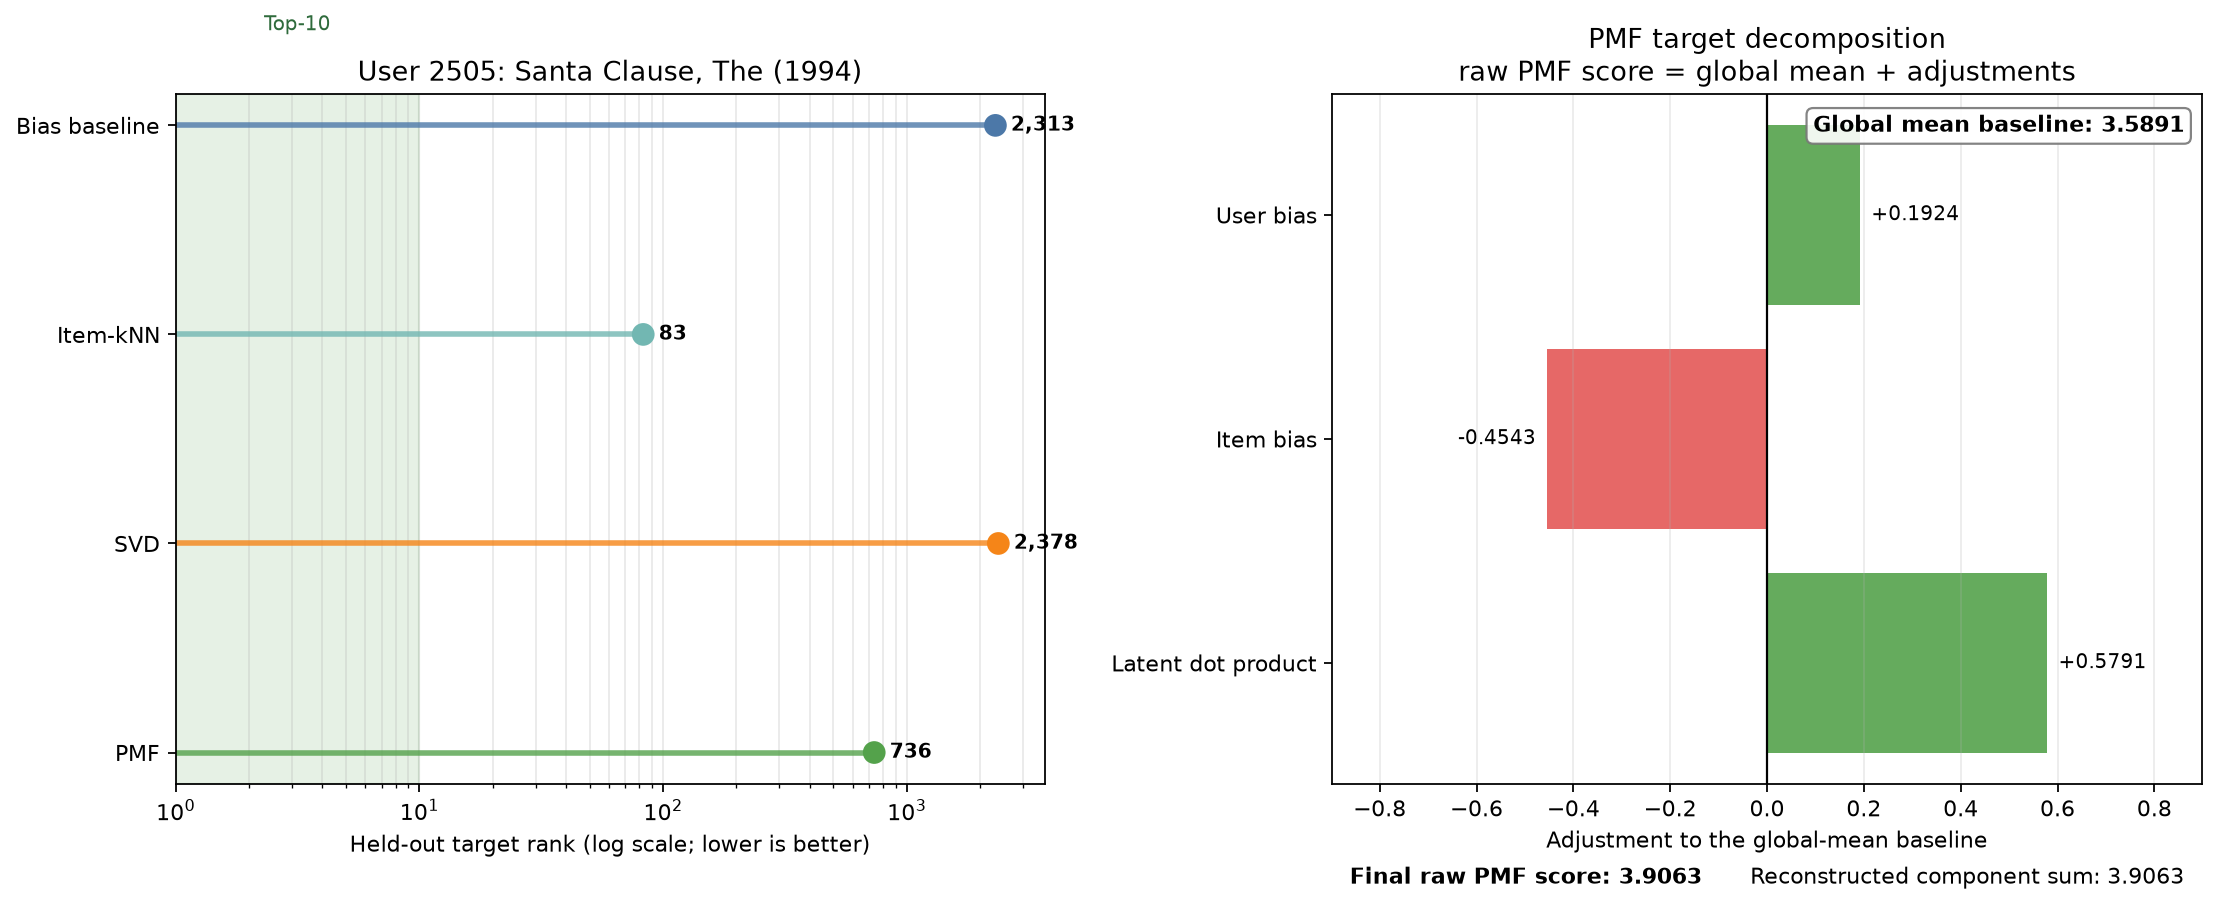

In [19]:
hit_miss = evaluated.loc[evaluated["role"].isin([
    "train_profile_accurate", "train_profile_less_accurate"
])]
display(hit_miss)
for selected in hit_miss.itertuples(index=False):
    user_id = int(selected.user_id)
    case = pd.read_csv(REPORTS / f"user_{user_id}_ranking_case.csv")
    print(f"\n{selected.role}: user {user_id}")
    display(case)
    display(Image(filename=str(REPORTS / f"user_{user_id}_ranking_case.png")))

## 16. Local Recommendation Explanations

Production Top-10 recommendation explanations remain separate from the
temporal target cases. Each PMF recommendation score is decomposed into
global mean, biases, and latent dot product.

User 2739 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2739,train_profile_accurate,1,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.463041,4.463041,3.582113,-0.173311,...,0.014194,"[{""contribution"": 0.026635882768913932, ""facto...",4.463041,0.0,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,5.0,0.687614,Action|Adventure
1,2739,train_profile_accurate,2,318,"Shawshank Redemption, The (1994)",Drama,4.420349,4.420349,3.582113,-0.173311,...,0.013942,"[{""contribution"": 0.014975625589896069, ""facto...",4.420349,0.0,2762,"Sixth Sense, The (1999)",Thriller,4.0,0.432737,NaN
2,2739,train_profile_accurate,3,2905,Sanjuro (1962),Action|Adventure,4.415621,4.415621,3.582113,-0.173311,...,-0.009105,"[{""contribution"": -0.013860299852087588, ""fact...",4.415621,0.0,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,5.0,0.289307,Action|Adventure


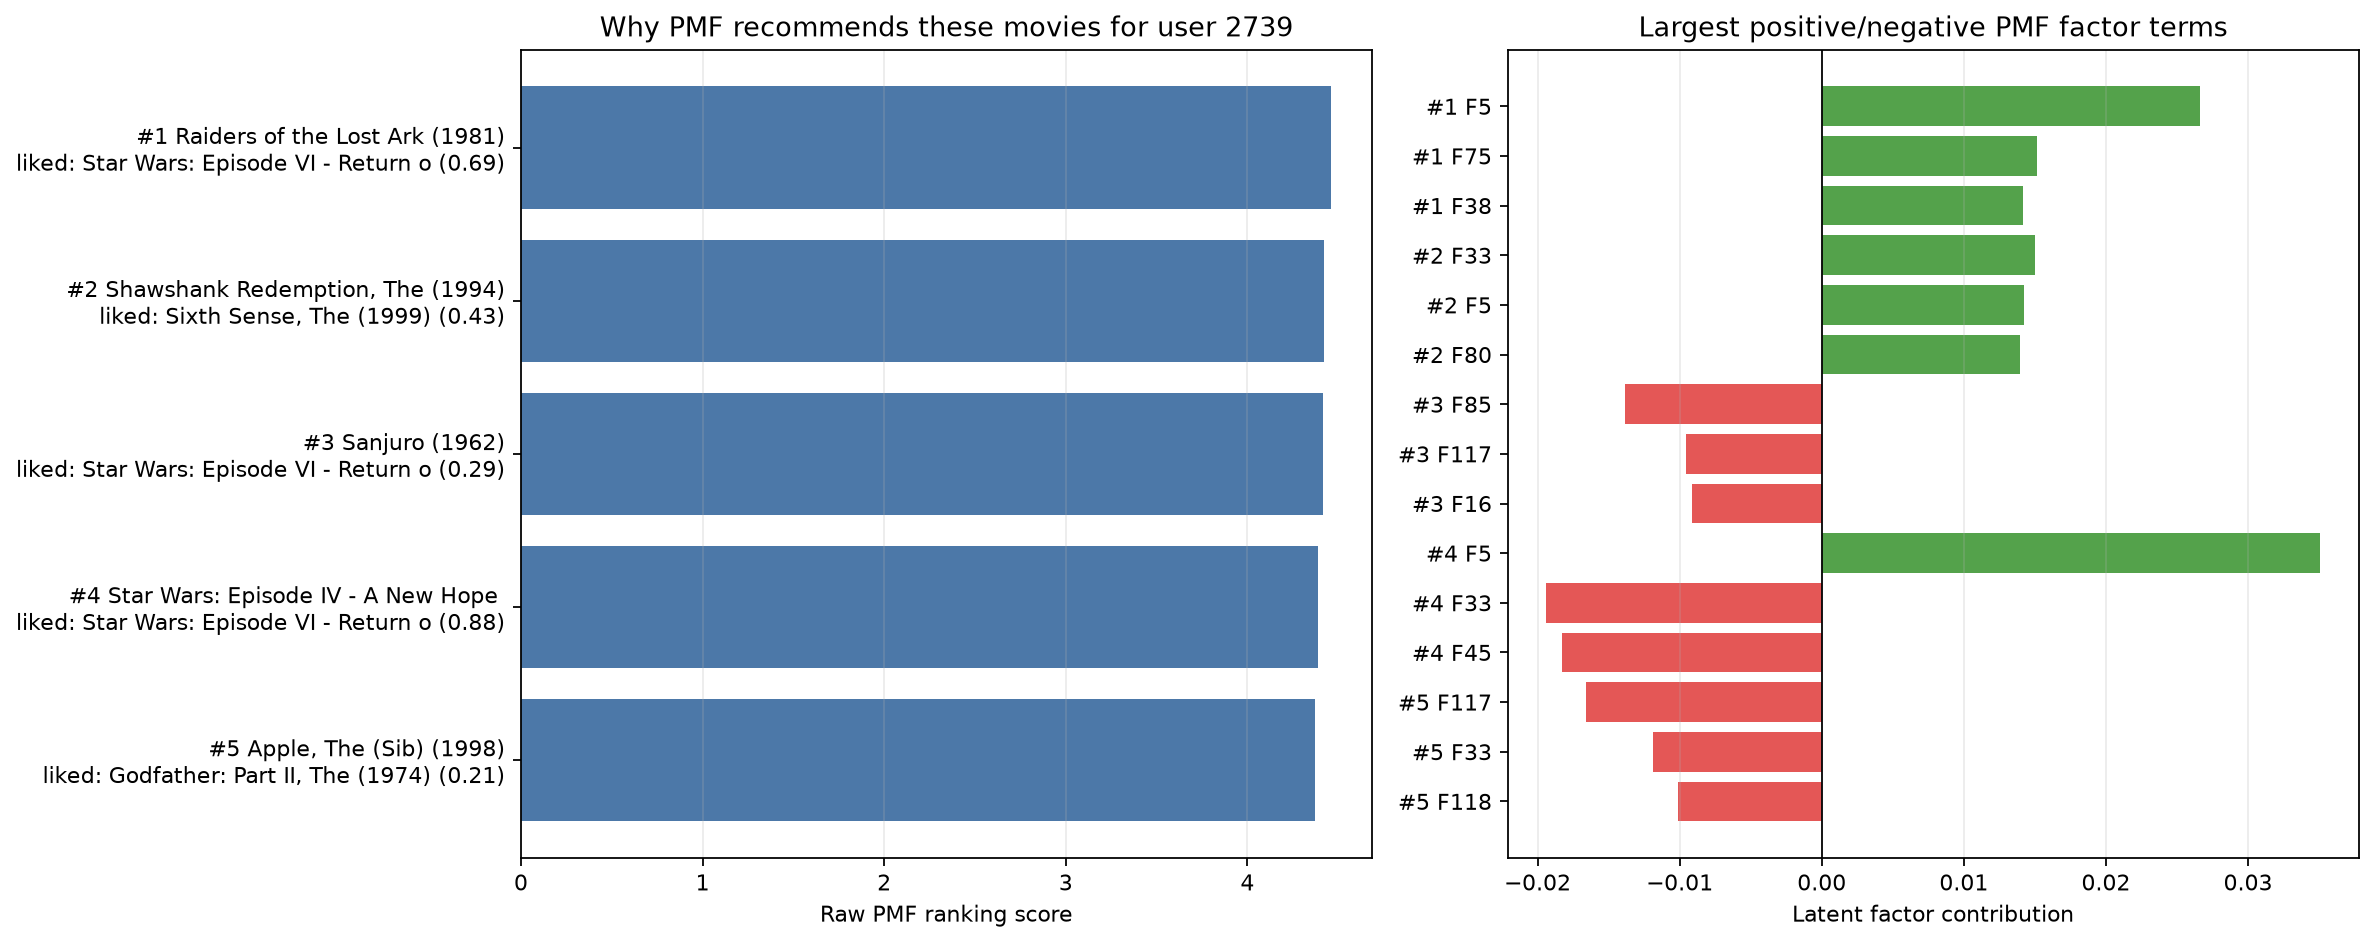

User 2505 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2505,train_profile_less_accurate,1,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.907337,4.907337,3.582113,0.13809,...,0.025511,"[{""contribution"": -0.030788455904713352, ""fact...",4.907337,0.0,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,5.0,0.829514,Action|Adventure
1,2505,train_profile_less_accurate,2,2762,"Sixth Sense, The (1999)",Thriller,4.894681,4.894681,3.582113,0.13809,...,0.028094,"[{""contribution"": 0.039822109267812156, ""facto...",4.894681,0.0,356,Forrest Gump (1994),Comedy|Romance|War,5.0,0.449039,NaN
2,2505,train_profile_less_accurate,3,1036,Die Hard (1988),Action|Thriller,4.889668,4.889668,3.582113,0.13809,...,0.034552,"[{""contribution"": 0.047019024829735745, ""facto...",4.889668,0.0,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,5.0,0.719067,Action|Thriller


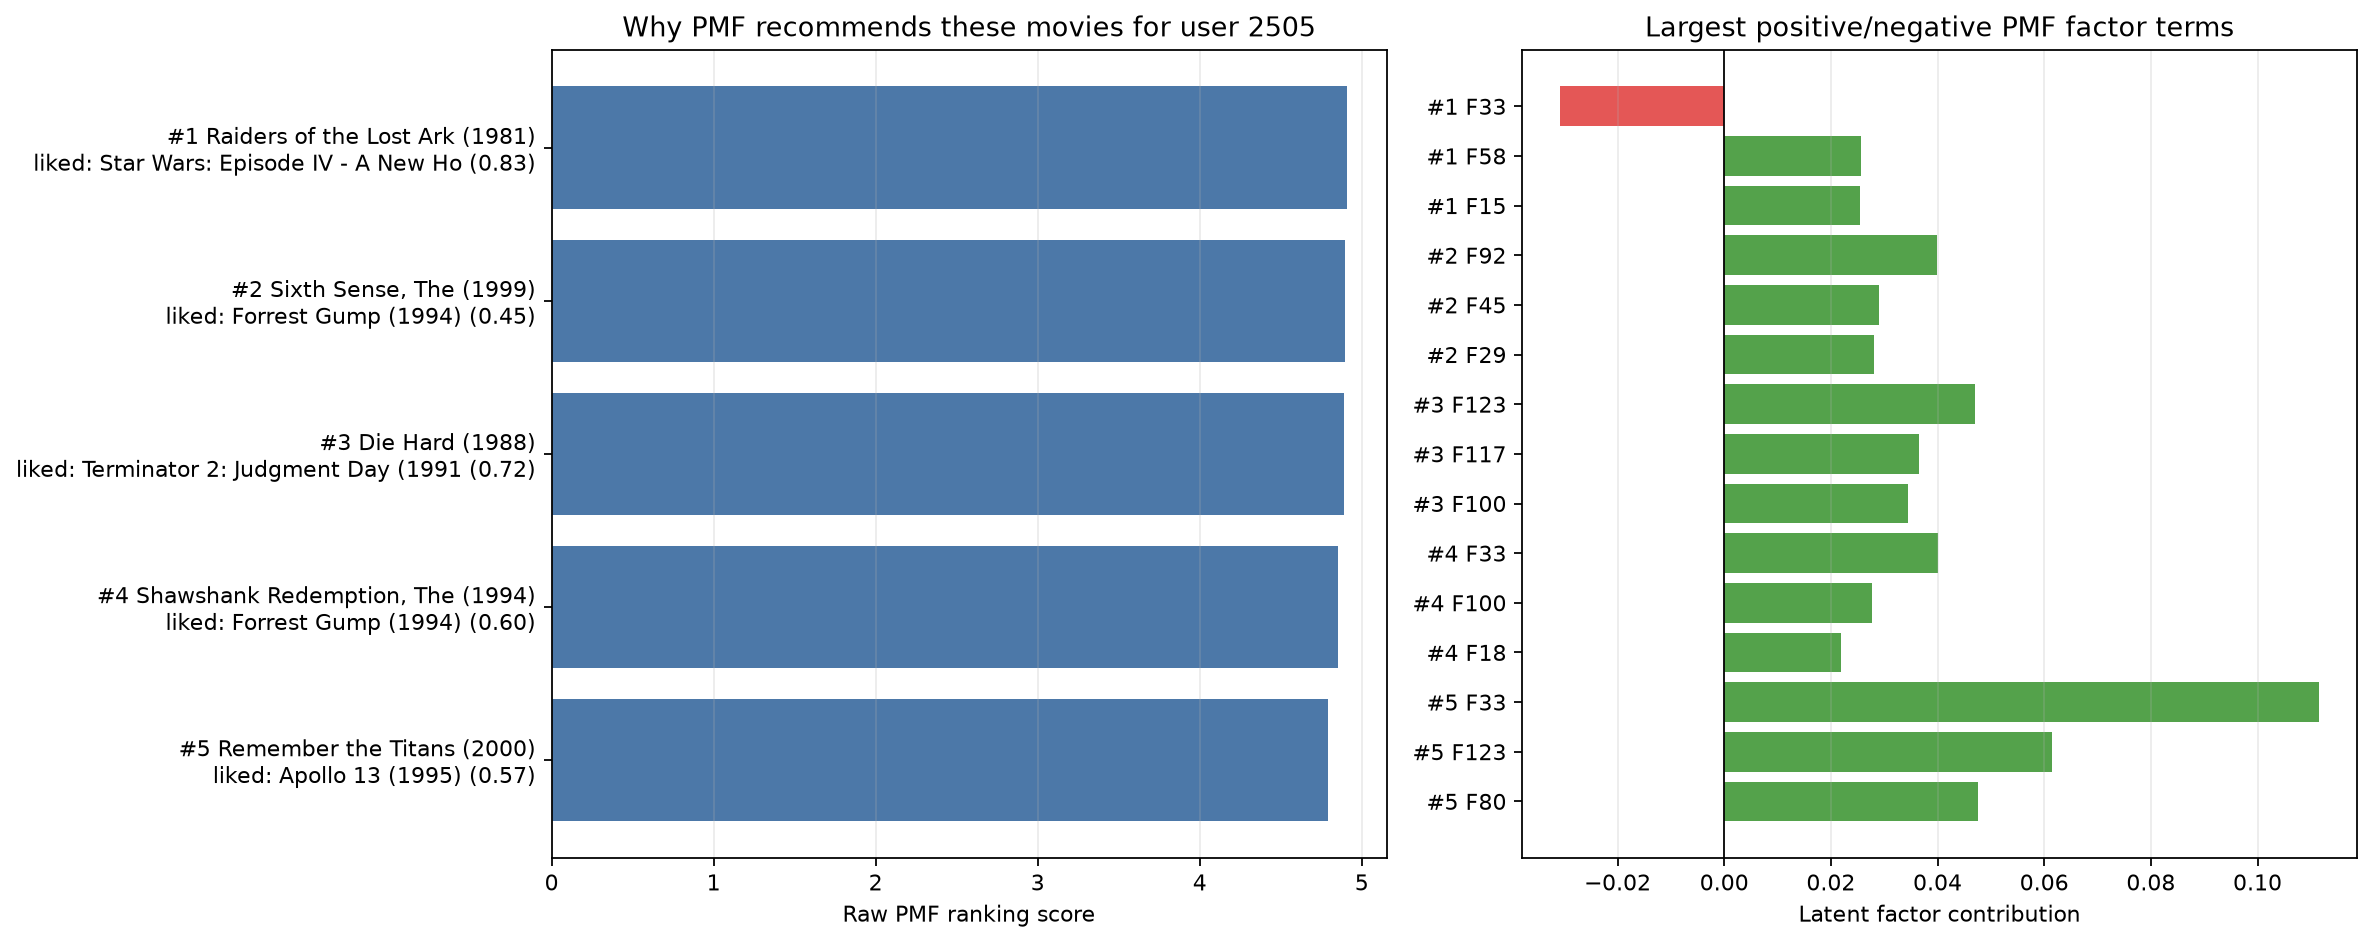

User 2210 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2210,test_case,1,2503,"Apple, The (Sib) (1998)",Drama,4.534943,4.534943,3.582113,-0.155831,...,-0.007482,"[{""contribution"": 0.010854569371102074, ""facto...",4.534943,0.0,3163,Topsy-Turvy (1999),Drama,4.0,0.192423,Drama
1,2210,test_case,2,2905,Sanjuro (1962),Action|Adventure,4.520885,4.520885,3.582113,-0.155831,...,0.008997,"[{""contribution"": 0.012714283598991294, ""facto...",4.520885,0.0,3911,Best in Show (2000),Comedy,4.0,0.331455,NaN
2,2210,test_case,3,3338,For All Mankind (1989),Documentary,4.515488,4.515488,3.582113,-0.155831,...,0.015108,"[{""contribution"": 0.018539101823794812, ""facto...",4.515488,0.0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,5.0,0.363946,NaN


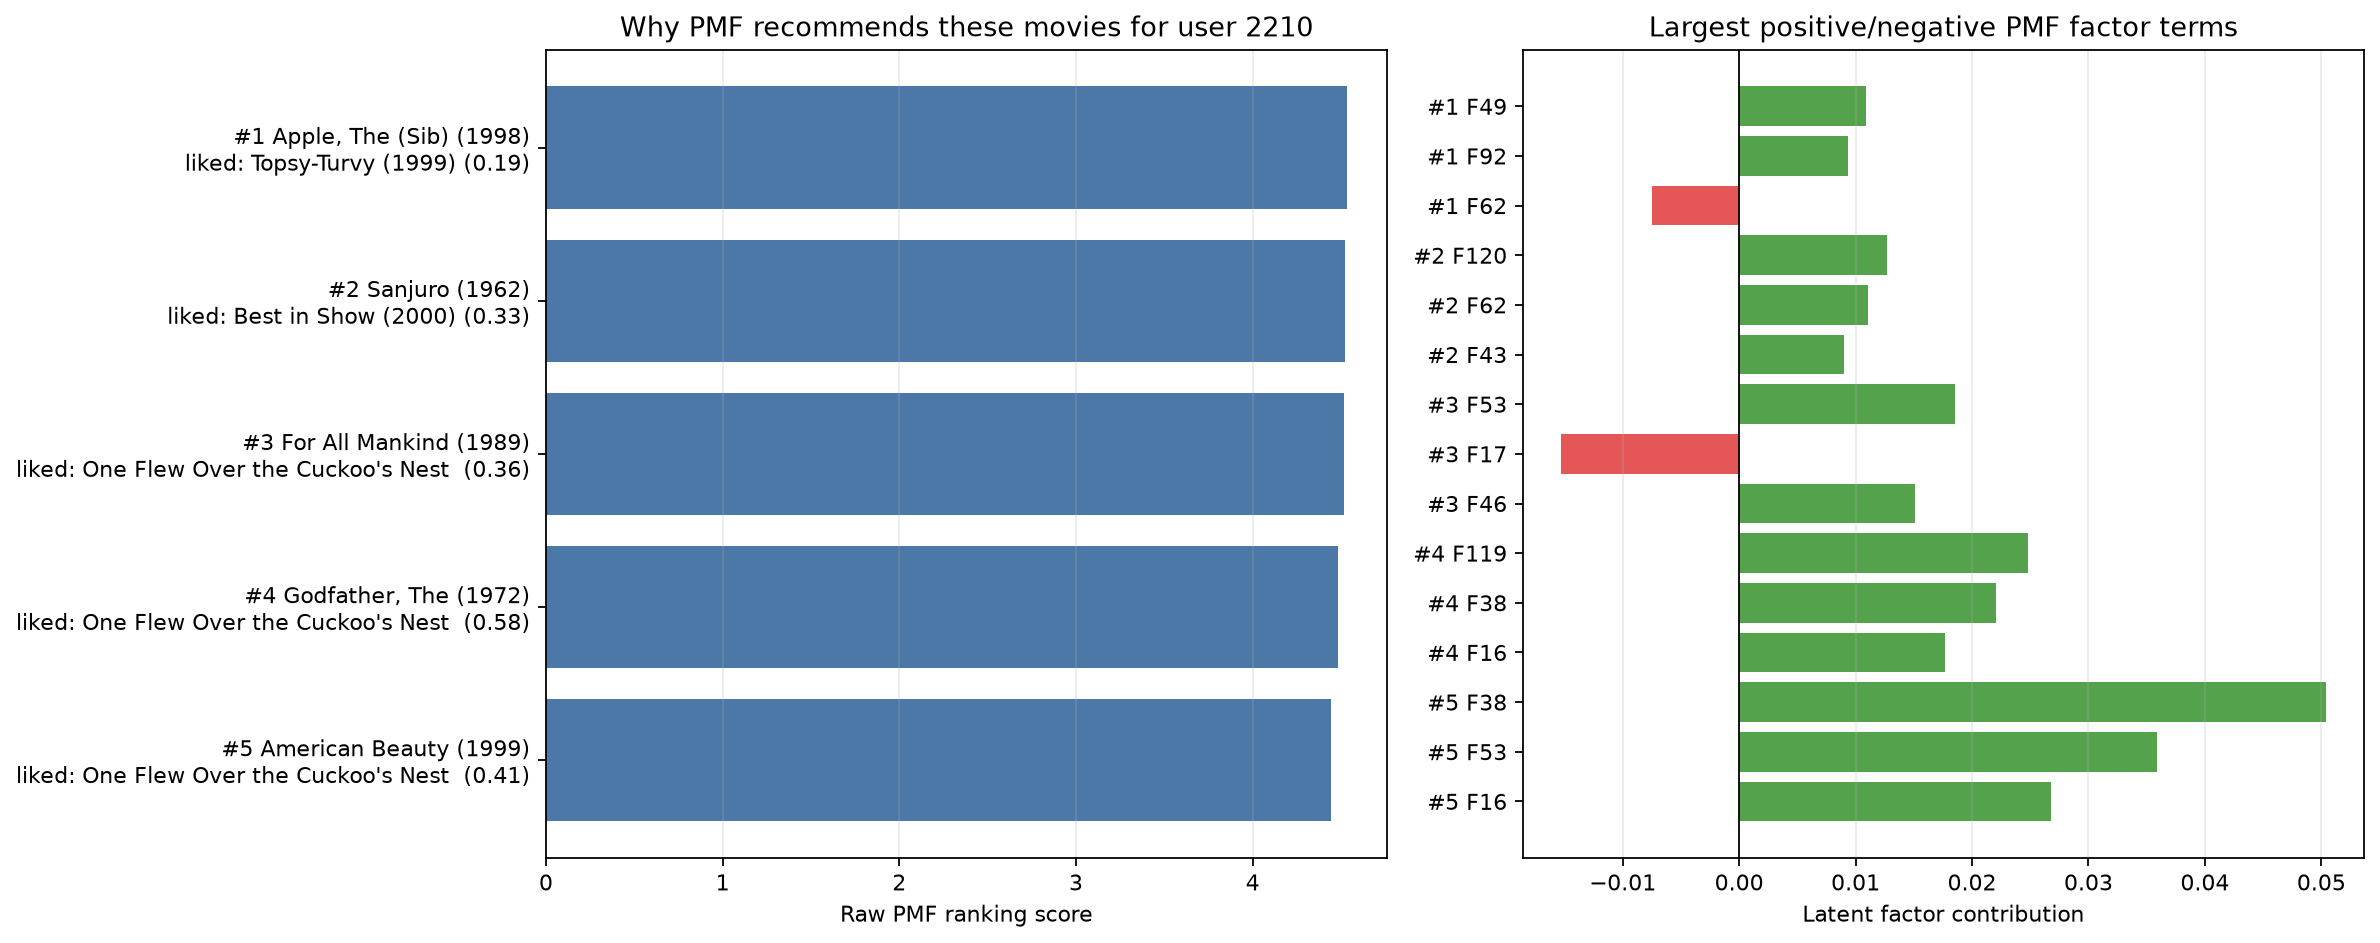

In [20]:
for selected in evaluated.itertuples(index=False):
    user_id = int(selected.user_id)
    explanations = pd.read_csv(
        REPORTS / f"user_{user_id}_explanations.csv"
    )
    print(
        f"User {user_id} max production explanation error:",
        explanations["reconstruction_error"].abs().max(),
    )
    display(explanations.head(3))
    display(Image(filename=str(REPORTS / f"user_{user_id}_explanation.png")))

## 17. Streamlit and artifact overview

Streamlit reads saved artifacts for both rating and ranking evaluation,
including separate MSE/RMSE comparisons and convergence views.

In [21]:
artifacts = [
    "model_metrics.json", "model_mse_comparison.png",
    "rmse_comparison.png", "pmf_convergence_mse.png",
    "pmf_convergence.png", "svd_rank_tuning_mse.png",
    "svd_rank_tuning_rmse.png", "ranking_protocol.json",
    "ranking_metrics.json", "ranking_results.csv",
    "ranking_comparison.png", "evaluated_users.json",
]
display(pd.DataFrame({
    "artifact": artifacts,
    "exists": [(REPORTS / name).exists() for name in artifacts],
}))

,artifact,exists
0,model_metrics.json,True
1,model_mse_comparison.png,True
2,rmse_comparison.png,True
3,pmf_convergence_mse.png,True
4,pmf_convergence.png,True
5,svd_rank_tuning_mse.png,True
6,svd_rank_tuning_rmse.png,True
7,ranking_protocol.json,True
8,ranking_metrics.json,True
9,ranking_results.csv,True


## 18. Limitations

The models use collaborative ratings only and do not solve cold start.
RMSE, typical target rank, and extreme-head retrieval can produce
different model orderings. The temporal protocol evaluates one known
future positive and has no observed true negatives. PMF factor
interpretations are descriptive, and the selected factor count remains
at the searched boundary.